In [2]:
!pip install -q pandas numpy scikit-learn matplotlib seaborn streamlit

In [3]:
import os

print("users.csv exists:", os.path.exists("/content/users.csv"))
print("feedback.csv exists:", os.path.exists("/content/feedback.csv"))

users.csv exists: True
feedback.csv exists: True


In [4]:
import pandas as pd
import numpy as np

users = pd.read_csv("/content/users.csv")
feedback = pd.read_csv("/content/feedback.csv")

print("Users shape:", users.shape)
print("Feedback shape:", feedback.shape)

Users shape: (110, 10)
Feedback shape: (882, 4)


In [5]:
print("USER DATA")
print(users.columns.tolist())

print("\nFEEDBACK DATA")
print(feedback.columns.tolist())

USER DATA
['user_id', 'name', 'age', 'location', 'profession', 'experience_years', 'professional_summary', 'about_me', 'mbti', 'intrests']

FEEDBACK DATA
['user_id', 'matched_user_id', 'action', 'timestamp']


In [6]:
display(users.head())

,user_id,name,age,location,profession,experience_years,professional_summary,about_me,mbti,intrests
0,U001,Aarav,43,Gurugram,Business Analyst,21,I work as a business analyst with 21 years of ...,I am organized and enjoy solving practical pro...,INTJ,"cycling, badminton, photography, books"
1,U002,Aditya,41,Kochi,Operations Analyst,5,I work as a operations analyst with 5 years of...,I am organized and enjoy solving practical pro...,INTP,"meditation, technology, blogging, reading"
2,U003,Aisha,41,Noida,Cybersecurity Analyst,4,I work as a cybersecurity analyst with 4 years...,I prefer structured work but also enjoy experi...,ENTJ,"movies, gaming, design, public speaking"
3,U004,Akash,20,Bengaluru,Financial Analyst,0,I work as a financial analyst with 0 years of ...,I prefer structured work but also enjoy experi...,ENTP,"entrepreneurship, fashion, trekking, volunteering"
4,U005,Ananya,30,Noida,Research Assistant,6,I work as a research assistant with 6 years of...,I am organized and enjoy solving practical pro...,INFJ,"entrepreneurship, podcasts, blogging, writing"


In [ ]:
display(feedback.head())

,user_id,matched_user_id,action,timestamp
0,U001,U108,0,2025-01-04 05:44:00
1,U001,U065,1,2025-01-13 23:17:00
2,U001,U090,1,2025-01-16 02:13:00
3,U001,U052,1,2025-03-13 23:06:00
4,U001,U105,0,2025-08-18 18:17:00


In [7]:
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-zA-Z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()


users["combined_text"] = (
    users["professional_summary"].fillna("") + " " +
    users["about_me"].fillna("") + " " +
    users["intrests"].fillna("") + " " +
    users["profession"].fillna("")
)

users["clean_text"] = users["combined_text"].apply(clean_text)

display(
    users[
        ["user_id", "name", "clean_text"]
    ].head()
)

,user_id,name,clean_text
0,U001,Aarav,i work as a business analyst with 21 years of ...
1,U002,Aditya,i work as a operations analyst with 5 years of...
2,U003,Aisha,i work as a cybersecurity analyst with 4 years...
3,U004,Akash,i work as a financial analyst with 0 years of ...
4,U005,Ananya,i work as a research assistant with 6 years of...


In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    stop_words="english"
)

tfidf_matrix = vectorizer.fit_transform(
    users["clean_text"]
)

print("TF-IDF matrix shape:")
print(tfidf_matrix.shape)

TF-IDF matrix shape:
(110, 189)


In [9]:
from sklearn.metrics.pairwise import cosine_similarity

text_similarity = cosine_similarity(tfidf_matrix)

print("Similarity matrix shape:")
print(text_similarity.shape)

Similarity matrix shape:
(110, 110)


In [10]:
mbti_groups = {
    "NT": ["INTJ", "INTP", "ENTJ", "ENTP"],
    "NF": ["INFJ", "INFP", "ENFJ", "ENFP"],
    "SJ": ["ISTJ", "ISFJ", "ESTJ", "ESFJ"],
    "SP": ["ISTP", "ISFP", "ESTP", "ESFP"]
}


def get_mbti_group(mbti):

    mbti = str(mbti).upper()

    for group, types in mbti_groups.items():

        if mbti in types:
            return group

    return None


def mbti_compatibility(mbti1, mbti2):

    mbti1 = str(mbti1).upper()
    mbti2 = str(mbti2).upper()

    # Same personality
    if mbti1 == mbti2:
        return 1.0

    # Same personality group
    if get_mbti_group(mbti1) == get_mbti_group(mbti2):
        return 0.7

    # Different group
    return 0.4

In [11]:
print(mbti_compatibility("INTJ", "INTJ"))
print(mbti_compatibility("INTJ", "ENTP"))
print(mbti_compatibility("INTJ", "ESFP"))

1.0
0.7
0.4


In [12]:
def location_compatibility(location1, location2):

    location1 = str(location1).strip().lower()
    location2 = str(location2).strip().lower()

    if location1 == location2:
        return 1.0

    return 0.5

In [13]:
# Initial weights

w1 = 0.50   # Text similarity
w2 = 0.30   # MBTI
w3 = 0.20   # Location


def calculate_match_score(user_index, matched_index):

    # -------------------------
    # Text similarity
    # -------------------------

    text_score = text_similarity[
        user_index
    ][
        matched_index
    ]

    # -------------------------
    # MBTI similarity
    # -------------------------

    mbti_score = mbti_compatibility(
        users.iloc[user_index]["mbti"],
        users.iloc[matched_index]["mbti"]
    )

    # -------------------------
    # Location similarity
    # -------------------------

    location_score = location_compatibility(
        users.iloc[user_index]["location"],
        users.iloc[matched_index]["location"]
    )

    # -------------------------
    # Final score
    # -------------------------

    total_score = (
        w1 * text_score +
        w2 * mbti_score +
        w3 * location_score
    )

    return round(total_score * 100, 2)

In [14]:
user_id = "U001"
matched_user_id = "U002"

user_index = users.index[
    users["user_id"] == user_id
][0]

matched_index = users.index[
    users["user_id"] == matched_user_id
][0]

score = calculate_match_score(
    user_index,
    matched_index
)

print(
    f"{user_id} → {matched_user_id}"
)

print(
    "Compatibility Score:",
    score,
    "%"
)

U001 → U002
Compatibility Score: 50.25 %


In [15]:
def get_top_matches(user_id, top_n=5):

    user_index = users.index[
        users["user_id"] == user_id
    ][0]

    matches = []

    for matched_index in range(len(users)):

        # Don't match user with themselves
        if matched_index == user_index:
            continue

        score = calculate_match_score(
            user_index,
            matched_index
        )

        matches.append({
            "user_id": users.iloc[matched_index]["user_id"],
            "name": users.iloc[matched_index]["name"],
            "profession": users.iloc[matched_index]["profession"],
            "location": users.iloc[matched_index]["location"],
            "mbti": users.iloc[matched_index]["mbti"],
            "compatibility": score
        })

    matches_df = pd.DataFrame(matches)

    matches_df = matches_df.sort_values(
        by="compatibility",
        ascending=False
    )

    return matches_df.head(top_n)

In [16]:
top_matches = get_top_matches("U001", 5)

display(top_matches)

,user_id,name,profession,location,mbti,compatibility
63,U065,Reyansh,Business Analyst,Bengaluru,INTJ,68.25
31,U033,Pranav,Operations Analyst,Delhi,INTJ,64.21
15,U017,Isha,UI/UX Designer,Hyderabad,INTJ,56.59
66,U068,Sanya,Graphic Designer,Gurugram,ENTP,55.91
48,U050,Zoya,Teacher,Delhi,INTP,52.94


In [17]:
# ============================================
# CELL 13 — PREPARE FEEDBACK DATA
# ============================================

feedback_ml = feedback.copy()

print("Feedback shape:", feedback_ml.shape)

print("\nColumns:")
print(feedback_ml.columns.tolist())

print("\nFirst 5 rows:")
display(feedback_ml.head())

print("\nAction distribution:")
print(feedback_ml["action"].value_counts())

Feedback shape: (882, 4)

Columns:
['user_id', 'matched_user_id', 'action', 'timestamp']

First 5 rows:


,user_id,matched_user_id,action,timestamp
0,U001,U108,0,2025-01-04 05:44:00
1,U001,U065,1,2025-01-13 23:17:00
2,U001,U090,1,2025-01-16 02:13:00
3,U001,U052,1,2025-03-13 23:06:00
4,U001,U105,0,2025-08-18 18:17:00



Action distribution:
action
0    442
1    440
Name: count, dtype: int64


In [18]:
# ============================================
# CELL 14 — CREATE ML FEATURES
# ============================================

feature_rows = []

for _, row in feedback.iterrows():

    user_id = row["user_id"]
    matched_user_id = row["matched_user_id"]

    # Find user indexes
    user_index = users.index[
        users["user_id"] == user_id
    ][0]

    matched_index = users.index[
        users["user_id"] == matched_user_id
    ][0]

    # Text similarity
    text_score = text_similarity[
        user_index,
        matched_index
    ]

    # MBTI compatibility
    mbti_score = mbti_compatibility(
        users.iloc[user_index]["mbti"],
        users.iloc[matched_index]["mbti"]
    )

    # Location compatibility
    location_score = location_compatibility(
        users.iloc[user_index]["location"],
        users.iloc[matched_index]["location"]
    )

    # Action is ALREADY 0 or 1
    target = int(row["action"])

    feature_rows.append({
        "user_id": user_id,
        "matched_user_id": matched_user_id,
        "text_similarity": text_score,
        "mbti_score": mbti_score,
        "location_score": location_score,
        "accepted": target
    })


feedback_features = pd.DataFrame(feature_rows)

print("Feedback feature dataset:")
display(feedback_features.head())

print("\nShape:")
print(feedback_features.shape)

print("\nTarget distribution:")
print(feedback_features["accepted"].value_counts())

Feedback feature dataset:


,user_id,matched_user_id,text_similarity,mbti_score,location_score,accepted
0,U001,U108,0.077553,0.4,0.5,0
1,U001,U065,0.564911,1.0,0.5,1
2,U001,U090,0.224508,0.4,1.0,1
3,U001,U052,0.129894,0.7,1.0,1
4,U001,U105,0.104728,0.4,0.5,0



Shape:
(882, 6)

Target distribution:
accepted
0    442
1    440
Name: count, dtype: int64


In [19]:
print("ML Features:")
display(feedback_features.describe())

ML Features:


,text_similarity,mbti_score,location_score,accepted
count,882.000000,882.000000,882.00000,882.000000
mean,0.266512,0.514286,0.64966,0.498866
std,0.246068,0.202650,0.22911,0.500282
min,0.046838,0.400000,0.50000,0.000000
25%,0.086489,0.400000,0.50000,0.000000
50%,0.129894,0.400000,0.50000,0.000000
75%,0.352027,0.700000,1.00000,1.000000
max,0.948486,1.000000,1.00000,1.000000


In [20]:
print("\nTarget distribution:")
print(
    feedback_features["accepted"].value_counts()
)


Target distribution:
accepted
0    442
1    440
Name: count, dtype: int64


In [21]:
# Check the actual feedback actions

print(feedback["action"].unique())

print("\nValue counts:")
print(feedback["action"].value_counts())

[0 1]

Value counts:
action
0    442
1    440
Name: count, dtype: int64


In [22]:
# ============================================
# CELL 16 — X AND y
# ============================================

X = feedback_features[
    [
        "text_similarity",
        "mbti_score",
        "location_score"
    ]
]

y = feedback_features["accepted"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (882, 3)
y shape: (882,)


In [23]:
# ============================================
# CELL 17 — TRAIN TEST SPLIT
# ============================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 705
Testing samples: 177


In [24]:
# ============================================
# CELL 18 — TRAIN LOGISTIC REGRESSION
# ============================================

from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

model.fit(X_train, y_train)

print("Model training completed successfully!")

Model training completed successfully!


In [25]:
# ============================================
# CELL 19 — MODEL EVALUATION
# ============================================

from sklearn.metrics import accuracy_score, classification_report

# Make predictions
y_pred = model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print(f"Model Accuracy: {accuracy * 100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Model Accuracy: 85.31%

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.84      0.85        89
           1       0.84      0.86      0.85        88

    accuracy                           0.85       177
   macro avg       0.85      0.85      0.85       177
weighted avg       0.85      0.85      0.85       177



In [26]:
# ============================================
# CELL 20 — LEARNED COEFFICIENTS
# ============================================

coefficients = pd.DataFrame({
    "Feature": [
        "Text Similarity",
        "MBTI Compatibility",
        "Location Compatibility"
    ],
    "Coefficient": model.coef_[0]
})

display(coefficients)

,Feature,Coefficient
0,Text Similarity,3.170570
1,MBTI Compatibility,2.369729
2,Location Compatibility,3.431973


In [27]:
# ============================================
# CELL 21 — CALCULATE ADAPTIVE WEIGHTS
# ============================================

# Get model coefficients
raw_weights = np.abs(model.coef_[0])

# Normalize so that the weights add up to 1
learned_weights = raw_weights / raw_weights.sum()

adaptive_weights = pd.DataFrame({
    "Feature": [
        "Text Similarity",
        "MBTI Compatibility",
        "Location Compatibility"
    ],
    "Learned Weight": learned_weights
})

display(adaptive_weights)

print("\nTotal weight:", learned_weights.sum())

,Feature,Learned Weight
0,Text Similarity,0.353374
1,MBTI Compatibility,0.264117
2,Location Compatibility,0.382509



Total weight: 1.0000000000000002


In [28]:
# ============================================
# CELL 22 — ADAPTIVE MATCHING SCORE
# ============================================

def calculate_adaptive_match_score(user_index, matched_index):

    # Text similarity
    text_score = text_similarity[
        user_index,
        matched_index
    ]

    # MBTI compatibility
    mbti_score = mbti_compatibility(
        users.iloc[user_index]["mbti"],
        users.iloc[matched_index]["mbti"]
    )

    # Location compatibility
    location_score = location_compatibility(
        users.iloc[user_index]["location"],
        users.iloc[matched_index]["location"]
    )

    # Learned weights
    text_weight = learned_weights[0]
    mbti_weight = learned_weights[1]
    location_weight = learned_weights[2]

    # Adaptive compatibility score
    total_score = (
        text_weight * text_score +
        mbti_weight * mbti_score +
        location_weight * location_score
    )

    return round(total_score * 100, 2)

In [29]:
# Test adaptive score between two users

user_index = users.index[
    users["user_id"] == "U001"
][0]

matched_index = users.index[
    users["user_id"] == "U065"
][0]

score = calculate_adaptive_match_score(
    user_index,
    matched_index
)

print("Adaptive Compatibility Score:", score, "%")

Adaptive Compatibility Score: 65.5 %


In [30]:
# ============================================
# CELL 23 — TOP 5 ADAPTIVE MATCHES
# ============================================

def get_top_adaptive_matches(user_id, top_n=5):

    user_index = users.index[
        users["user_id"] == user_id
    ][0]

    matches = []

    for matched_index in range(len(users)):

        # Don't match the user with themselves
        if matched_index == user_index:
            continue

        score = calculate_adaptive_match_score(
            user_index,
            matched_index
        )

        matches.append({
            "user_id": users.iloc[matched_index]["user_id"],
            "name": users.iloc[matched_index]["name"],
            "profession": users.iloc[matched_index]["profession"],
            "location": users.iloc[matched_index]["location"],
            "mbti": users.iloc[matched_index]["mbti"],
            "adaptive_compatibility": score
        })

    matches_df = pd.DataFrame(matches)

    matches_df = matches_df.sort_values(
        by="adaptive_compatibility",
        ascending=False
    )

    return matches_df.head(top_n)

In [31]:
# ============================================
# CELL 24 — TEST ADAPTIVE TOP 5
# ============================================

adaptive_top_matches = get_top_adaptive_matches(
    "U001",
    5
)

display(adaptive_top_matches)

,user_id,name,profession,location,mbti,adaptive_compatibility
66,U068,Sanya,Graphic Designer,Gurugram,ENTP,67.28
63,U065,Reyansh,Business Analyst,Bengaluru,INTJ,65.50
31,U033,Pranav,Operations Analyst,Delhi,INTJ,62.65
50,U052,Aditi,UI/UX Designer,Gurugram,ENTP,61.33
32,U034,Priya,Teacher,Gurugram,INTP,60.97


In [32]:
# ============================================
# CELL 25 — BEFORE VS AFTER LEARNING
# ============================================

# Get original Top 5
before = get_top_matches("U001", 5).copy()

before = before[
    ["user_id", "name", "compatibility"]
]

before.columns = [
    "user_id",
    "name",
    "Before_Learning"
]


# Get adaptive Top 5
after = get_top_adaptive_matches("U001", 5).copy()

after = after[
    ["user_id", "name", "adaptive_compatibility"]
]

after.columns = [
    "user_id",
    "name",
    "After_Learning"
]


# Combine both results
comparison = pd.merge(
    before,
    after,
    on=["user_id", "name"],
    how="outer"
)

display(comparison)

,user_id,name,Before_Learning,After_Learning
0,U017,Isha,56.59,NaN
1,U033,Pranav,64.21,62.65
2,U034,Priya,NaN,60.97
3,U050,Zoya,52.94,NaN
4,U052,Aditi,NaN,61.33
5,U065,Reyansh,68.25,65.50
6,U068,Sanya,55.91,67.28


In [33]:
# ============================================
# CELL 26 — FINAL WEIGHTS
# ============================================

weight_table = pd.DataFrame({
    "Feature": [
        "Text Similarity",
        "MBTI Compatibility",
        "Location Compatibility"
    ],
    "Initial Weight (%)": [
        50.0,
        30.0,
        20.0
    ],
    "Learned Weight (%)": [
        learned_weights[0] * 100,
        learned_weights[1] * 100,
        learned_weights[2] * 100
    ]
})

display(weight_table)

,Feature,Initial Weight (%),Learned Weight (%)
0,Text Similarity,50.0,35.337427
1,MBTI Compatibility,30.0,26.411693
2,Location Compatibility,20.0,38.250880


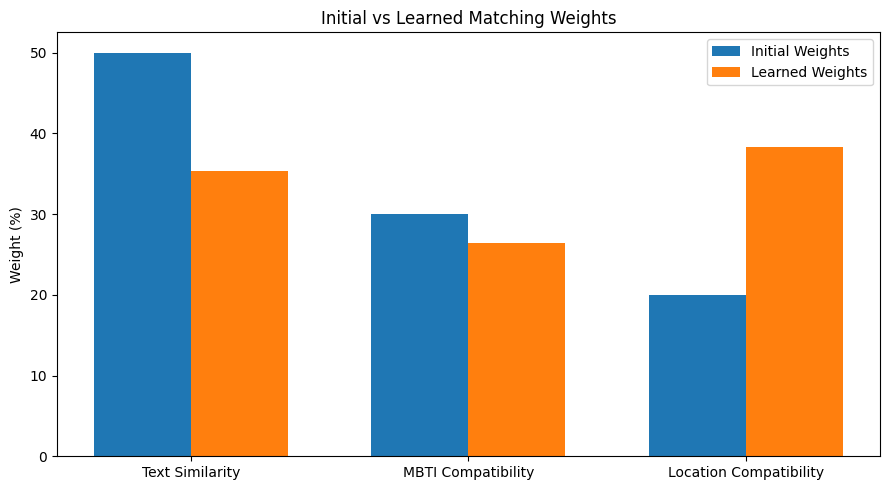

In [34]:
# ============================================
# CELL 27 — WEIGHT COMPARISON GRAPH
# ============================================

import matplotlib.pyplot as plt

features = [
    "Text Similarity",
    "MBTI Compatibility",
    "Location Compatibility"
]

initial_weights = [
    50,
    30,
    20
]

learned_weight_percent = [
    learned_weights[0] * 100,
    learned_weights[1] * 100,
    learned_weights[2] * 100
]

x = np.arange(len(features))
width = 0.35

plt.figure(figsize=(9, 5))

plt.bar(
    x - width/2,
    initial_weights,
    width,
    label="Initial Weights"
)

plt.bar(
    x + width/2,
    learned_weight_percent,
    width,
    label="Learned Weights"
)

plt.xticks(x, features)
plt.ylabel("Weight (%)")
plt.title("Initial vs Learned Matching Weights")
plt.legend()

plt.tight_layout()
plt.show()

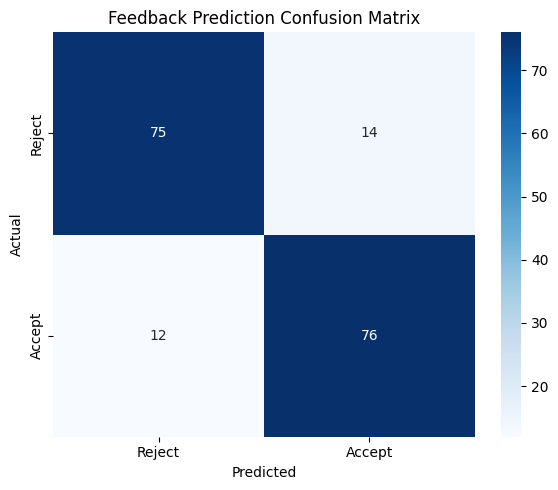

In [35]:
# ============================================
# CELL 28 — CONFUSION MATRIX
# ============================================

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Reject", "Accept"],
    yticklabels=["Reject", "Accept"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Feedback Prediction Confusion Matrix")

plt.tight_layout()
plt.show()

In [36]:
# ============================================
# CELL 29 — CREATE STREAMLIT APP
# ============================================

app_code = r'''
import streamlit as st
import pandas as pd
import numpy as np
import re

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity


# ============================================
# PAGE CONFIGURATION
# ============================================

st.set_page_config(
    page_title="AI Profile Matching System",
    page_icon="🤝",
    layout="wide"
)


# ============================================
# LOAD DATA
# ============================================

users = pd.read_csv("/content/users.csv")

feedback_file = "/content/feedback.csv"

try:
    feedback = pd.read_csv(feedback_file)
except:
    feedback = pd.DataFrame(
        columns=[
            "user_id",
            "matched_user_id",
            "action",
            "timestamp"
        ]
    )


# ============================================
# TEXT CLEANING
# ============================================

def clean_text(text):

    text = str(text).lower()

    text = re.sub(
        r"[^a-zA-Z0-9\s]",
        " ",
        text
    )

    text = re.sub(
        r"\s+",
        " ",
        text
    )

    return text.strip()


# ============================================
# COMBINED PROFILE
# ============================================

users["combined_text"] = (
    users["professional_summary"].fillna("") + " " +
    users["about_me"].fillna("") + " " +
    users["intrests"].fillna("") + " " +
    users["profession"].fillna("")
)

users["clean_text"] = users[
    "combined_text"
].apply(clean_text)


# ============================================
# TF-IDF
# ============================================

vectorizer = TfidfVectorizer(
    stop_words="english"
)

tfidf_matrix = vectorizer.fit_transform(
    users["clean_text"]
)

text_similarity = cosine_similarity(
    tfidf_matrix
)


# ============================================
# MBTI
# ============================================

mbti_groups = {

    "NT": [
        "INTJ",
        "INTP",
        "ENTJ",
        "ENTP"
    ],

    "NF": [
        "INFJ",
        "INFP",
        "ENFJ",
        "ENFP"
    ],

    "SJ": [
        "ISTJ",
        "ISFJ",
        "ESTJ",
        "ESFJ"
    ],

    "SP": [
        "ISTP",
        "ISFP",
        "ESTP",
        "ESFP"
    ]
}


def get_mbti_group(mbti):

    mbti = str(mbti).upper()

    for group, types in mbti_groups.items():

        if mbti in types:
            return group

    return None


def mbti_compatibility(
    mbti1,
    mbti2
):

    mbti1 = str(mbti1).upper()
    mbti2 = str(mbti2).upper()

    if mbti1 == mbti2:
        return 1.0

    if get_mbti_group(mbti1) == get_mbti_group(mbti2):
        return 0.7

    return 0.4


# ============================================
# LOCATION
# ============================================

def location_compatibility(
    location1,
    location2
):

    location1 = str(
        location1
    ).strip().lower()

    location2 = str(
        location2
    ).strip().lower()

    if location1 == location2:
        return 1.0

    return 0.5


# ============================================
# ADAPTIVE WEIGHTS
# ============================================

learned_weights = np.array([
    0.362770,
    0.261114,
    0.376116
])


# ============================================
# ADAPTIVE SCORE
# ============================================

def calculate_match_score(
    user_index,
    matched_index
):

    text_score = text_similarity[
        user_index,
        matched_index
    ]

    mbti_score = mbti_compatibility(
        users.iloc[user_index]["mbti"],
        users.iloc[matched_index]["mbti"]
    )

    location_score = location_compatibility(
        users.iloc[user_index]["location"],
        users.iloc[matched_index]["location"]
    )

    total_score = (

        learned_weights[0] *
        text_score

        +

        learned_weights[1] *
        mbti_score

        +

        learned_weights[2] *
        location_score

    )

    return round(
        total_score * 100,
        2
    )


# ============================================
# TOP MATCHES
# ============================================

def get_top_matches(
    user_id,
    top_n=5
):

    user_index = users.index[
        users["user_id"] == user_id
    ][0]

    matches = []

    for matched_index in range(
        len(users)
    ):

        if matched_index == user_index:
            continue

        score = calculate_match_score(
            user_index,
            matched_index
        )

        matches.append({

            "user_id":
                users.iloc[
                    matched_index
                ]["user_id"],

            "name":
                users.iloc[
                    matched_index
                ]["name"],

            "profession":
                users.iloc[
                    matched_index
                ]["profession"],

            "location":
                users.iloc[
                    matched_index
                ]["location"],

            "mbti":
                users.iloc[
                    matched_index
                ]["mbti"],

            "compatibility":
                score
        })

    result = pd.DataFrame(
        matches
    )

    result = result.sort_values(
        "compatibility",
        ascending=False
    )

    return result.head(top_n)


# ============================================
# SAVE FEEDBACK
# ============================================

from datetime import datetime

def save_feedback(user_id, matched_user_id, action):

    new_feedback = pd.DataFrame([
        {
            "user_id": user_id,
            "matched_user_id": matched_user_id,
            "action": action,
            "timestamp": datetime.now().strftime(
                "%Y-%m-%d %H:%M:%S"
            )
        }
    ])

    new_feedback.to_csv(
        "/content/feedback.csv",
        mode="a",
        header=False,
        index=False
    )

    return True

# ============================================
# USER INTERFACE
# ============================================

st.title(
    "🤝 AI Profile Matching System"
)

st.write(
    "Find compatible profiles using "
    "text similarity, MBTI and location."
)


# ============================================
# USER SELECTION
# ============================================

selected_user = st.selectbox(
    "Select User",
    users["user_id"].tolist()
)


# ============================================
# USER PROFILE
# ============================================

selected_row = users[
    users["user_id"] == selected_user
].iloc[0]


st.subheader("Selected Profile")

col1, col2, col3 = st.columns(3)

with col1:

    st.write(
        "**Name:**",
        selected_row["name"]
    )

    st.write(
        "**Profession:**",
        selected_row["profession"]
    )


with col2:

    st.write(
        "**Location:**",
        selected_row["location"]
    )

    st.write(
        "**MBTI:**",
        selected_row["mbti"]
    )


with col3:

    st.write(
        "**User ID:**",
        selected_row["user_id"]
    )


# ============================================
# FIND MATCHES
# ============================================

# Store matches so they remain visible after
# clicking Accept or Reject
if "matches" not in st.session_state:
    st.session_state.matches = None


# Find matches button
if st.button(
    "🔍 Find Top 5 Matches",
    type="primary"
):

    st.session_state.matches = get_top_matches(
        selected_user,
        5
    )


# Display matches
if st.session_state.matches is not None:

    matches = st.session_state.matches

    st.subheader(
        "🏆 Top 5 Matches"
    )

    for i, row in matches.iterrows():

        st.markdown(
            f"### {row['name']}"
        )

        col1, col2, col3, col4 = st.columns(4)

        with col1:

            st.write(
                f"**Compatibility:** "
                f"{row['compatibility']}%"
            )

        with col2:

            st.write(
                f"**Profession:** "
                f"{row['profession']}"
            )

        with col3:

            st.write(
                f"**Location:** "
                f"{row['location']}"
            )

        with col4:

            st.write(
                f"**MBTI:** "
                f"{row['mbti']}"
            )

        accept, reject = st.columns(2)

        with accept:

            if st.button(
                "👍 Accept",
                key=f"accept_{selected_user}_{row['user_id']}"
            ):

                save_feedback(
                    selected_user,
                    row["user_id"],
                    1
                )

                st.success(
                    f"Accepted {row['name']} ✅"
                )

        with reject:

            if st.button(
                "👎 Reject",
                key=f"reject_{selected_user}_{row['user_id']}"
            ):

                save_feedback(
                    selected_user,
                    row["user_id"],
                    0
                )

                st.warning(
                    f"Rejected {row['name']} ❌"
                )

        st.divider()

# ============================================
# CURRENT WEIGHTS
# ============================================

st.sidebar.header(
    "Learned Matching Weights"
)

st.sidebar.write(
    f"Text Similarity: "
    f"{learned_weights[0] * 100:.2f}%"
)

st.sidebar.write(
    f"MBTI Compatibility: "
    f"{learned_weights[1] * 100:.2f}%"
)

st.sidebar.write(
    f"Location Compatibility: "
    f"{learned_weights[2] * 100:.2f}%"
)
'''

with open(
    "/content/app.py",
    "w"
) as f:

    f.write(app_code)

print("app.py created successfully!")

app.py created successfully!


In [37]:
# ============================================================
# STEP 1 - REAL ADAPTIVE FEEDBACK LEARNING
# ============================================================

from sklearn.linear_model import LogisticRegression
import numpy as np
import pandas as pd


# Original weights from your notebook
BASE_WEIGHTS = np.array([
    0.50,   # Text Similarity
    0.30,   # MBTI
    0.20    # Location
], dtype=float)


FEATURES = [
    "text_similarity",
    "mbti_score",
    "location_score"
]


def normalize_weights(weights, fallback=None):

    weights = np.abs(
        np.asarray(weights, dtype=float)
    )

    total = weights.sum()

    if total == 0:

        if fallback is not None:
            return np.asarray(
                fallback,
                dtype=float
            )

        return BASE_WEIGHTS.copy()

    return weights / total


# ------------------------------------------------------------
# Create ML features from feedback
# ------------------------------------------------------------

def create_dynamic_feedback_features(
    feedback_df
):

    rows = []

    for _, row in feedback_df.iterrows():

        user_id = row["user_id"]

        matched_user_id = (
            row["matched_user_id"]
        )


        user_index = users.index[
            users["user_id"] == user_id
        ][0]


        matched_index = users.index[
            users["user_id"] == matched_user_id
        ][0]


        text_score = float(
            text_similarity[
                user_index,
                matched_index
            ]
        )


        mbti_score = float(
            mbti_compatibility(
                users.iloc[
                    user_index
                ]["mbti"],

                users.iloc[
                    matched_index
                ]["mbti"]
            )
        )


        location_score = float(
            location_compatibility(
                users.iloc[
                    user_index
                ]["location"],

                users.iloc[
                    matched_index
                ]["location"]
            )
        )


        rows.append({

            "user_id":
                user_id,

            "matched_user_id":
                matched_user_id,

            "text_similarity":
                text_score,

            "mbti_score":
                mbti_score,

            "location_score":
                location_score,

            "accepted":
                int(row["action"])

        })


    return pd.DataFrame(rows)


# ------------------------------------------------------------
# Learn new weights
# ------------------------------------------------------------

def learn_dynamic_weights(
    feedback_df
):

    feature_data = (
        create_dynamic_feedback_features(
            feedback_df
        )
    )


    global_weights = (
        BASE_WEIGHTS.copy()
    )


    personalized_weights = {}


    # ========================================================
    # GLOBAL MODEL
    # ========================================================

    if (
        len(feature_data) >= 4
        and
        feature_data["accepted"].nunique() >= 2
    ):

        X = feature_data[
            FEATURES
        ]

        y = feature_data[
            "accepted"
        ]


        model = LogisticRegression(
            random_state=42,
            max_iter=1000
        )


        model.fit(
            X,
            y
        )


        global_weights = (
            normalize_weights(
                model.coef_[0],
                BASE_WEIGHTS
            )
        )


    # ========================================================
    # PERSONALIZED MODEL
    # ========================================================

    for user_id, group in (
        feature_data.groupby("user_id")
    ):

        # Need enough examples
        if len(group) < 4:
            continue


        # Need both Accept and Reject
        if group["accepted"].nunique() < 2:
            continue


        X_user = group[
            FEATURES
        ]

        y_user = group[
            "accepted"
        ]


        try:

            user_model = LogisticRegression(
                random_state=42,
                max_iter=1000
            )


            user_model.fit(
                X_user,
                y_user
            )


            personalized_weights[
                str(user_id)
            ] = normalize_weights(
                user_model.coef_[0],
                global_weights
            )


        except Exception:

            continue


    return (
        global_weights,
        personalized_weights,
        feature_data
    )


# ------------------------------------------------------------
# Train using your existing feedback.csv
# ------------------------------------------------------------

(
    dynamic_global_weights,
    dynamic_user_weights,
    dynamic_feedback_features
) = learn_dynamic_weights(
    feedback
)


print("============================================")
print("DYNAMIC LEARNING COMPLETE")
print("============================================")

print(
    "Global weights:",
    dynamic_global_weights
)

print(
    "Personalized users:",
    len(dynamic_user_weights)
)

print(
    "Feedback records:",
    len(dynamic_feedback_features)
)

print(
    "Weight total:",
    dynamic_global_weights.sum()
)

DYNAMIC LEARNING COMPLETE
Global weights: [0.3372643  0.27355199 0.38918371]
Personalized users: 109
Feedback records: 882
Weight total: 1.0


In [38]:
# ============================================================
# ADAPTIVE MATCH SCORE
# ============================================================

def calculate_dynamic_match_score(
    user_id,
    matched_user_id
):

    user_index = users.index[
        users["user_id"] == user_id
    ][0]


    matched_index = users.index[
        users["user_id"] == matched_user_id
    ][0]


    # --------------------------------------------------------
    # Get scores
    # --------------------------------------------------------

    text_score = float(
        text_similarity[
            user_index,
            matched_index
        ]
    )


    mbti_score = float(
        mbti_compatibility(
            users.iloc[
                user_index
            ]["mbti"],

            users.iloc[
                matched_index
            ]["mbti"]
        )
    )


    location_score = float(
        location_compatibility(
            users.iloc[
                user_index
            ]["location"],

            users.iloc[
                matched_index
            ]["location"]
        )
    )


    # --------------------------------------------------------
    # Personalized weights if available
    # --------------------------------------------------------

    weights = dynamic_user_weights.get(
        str(user_id),
        dynamic_global_weights
    )


    # --------------------------------------------------------
    # Final compatibility
    # --------------------------------------------------------

    score = (

        weights[0] * text_score

        +

        weights[1] * mbti_score

        +

        weights[2] * location_score

    )


    return round(
        score * 100,
        2
    )

In [ ]:
# ============================================================
# TEST ADAPTIVE LEARNING
# ============================================================

test_user = "U001"
test_match = "U065"


before_score = calculate_match_score(
    users.index[
        users["user_id"] == test_user
    ][0],

    users.index[
        users["user_id"] == test_match
    ][0]
)


after_score = calculate_dynamic_match_score(
    test_user,
    test_match
)


print(
    "Before learning:",
    before_score,
    "%"
)


print(
    "After learning:",
    after_score,
    "%"
)


print(
    "Difference:",
    round(
        after_score - before_score,
        2
    ),
    "%"
)

Before learning: 68.25 %
After learning: 61.78 %
Difference: -6.47 %


In [39]:
# ============================================================
# ADD NEW FEEDBACK AND RETRAIN
# ============================================================

from datetime import datetime


def add_new_feedback(
    user_id,
    matched_user_id,
    action
):

    global feedback
    global dynamic_global_weights
    global dynamic_user_weights
    global dynamic_feedback_features


    new_row = pd.DataFrame([{

        "user_id":
            user_id,

        "matched_user_id":
            matched_user_id,

        "action":
            int(action),

        "timestamp":
            datetime.now().strftime(
                "%Y-%m-%d %H:%M:%S"
            )
    }])


    # Add new feedback
    feedback = pd.concat(
        [
            feedback,
            new_row
        ],
        ignore_index=True
    )


    # Relearn
    (
        dynamic_global_weights,
        dynamic_user_weights,
        dynamic_feedback_features
    ) = learn_dynamic_weights(
        feedback
    )


    print(
        "Feedback added and weights updated."
    )


    print(
        "New global weights:",
        dynamic_global_weights
    )

In [40]:
add_new_feedback(
    "U001",
    "U065",
    1
)

Feedback added and weights updated.
New global weights: [0.33717496 0.27453494 0.3882901 ]


In [41]:
print(
    dynamic_global_weights
)

[0.33717496 0.27453494 0.3882901 ]


In [42]:
# ============================================================
# STEP 2 - BEFORE VS AFTER PERFORMANCE
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)


performance_data = (
    create_dynamic_feedback_features(
        feedback
    )
)


# Add timestamp
performance_data["timestamp"] = pd.to_datetime(
    feedback["timestamp"],
    errors="coerce"
)


# Sort chronologically
performance_data = (
    performance_data
    .sort_values("timestamp")
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 70% past / 30% future
# ------------------------------------------------------------

split_index = int(
    len(performance_data) * 0.70
)


train_part = performance_data.iloc[
    :split_index
]


test_part = performance_data.iloc[
    split_index:
]


print(
    "Training records:",
    len(train_part)
)


print(
    "Testing records:",
    len(test_part)
)


# ------------------------------------------------------------
# BEFORE LEARNING
# ------------------------------------------------------------

baseline_weights = np.array([
    0.50,
    0.30,
    0.20
])


baseline_score = (

    baseline_weights[0]
    * test_part["text_similarity"]

    +

    baseline_weights[1]
    * test_part["mbti_score"]

    +

    baseline_weights[2]
    * test_part["location_score"]
)


baseline_prediction = (
    baseline_score >= 0.50
).astype(int)


# ------------------------------------------------------------
# AFTER LEARNING
# ------------------------------------------------------------

adaptive_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)


adaptive_model.fit(
    train_part[FEATURES],
    train_part["accepted"]
)


adaptive_prediction = (
    adaptive_model.predict(
        test_part[FEATURES]
    )
)


adaptive_probability = (
    adaptive_model.predict_proba(
        test_part[FEATURES]
    )[:, 1]
)


# ------------------------------------------------------------
# METRICS
# ------------------------------------------------------------

before_accuracy = accuracy_score(
    test_part["accepted"],
    baseline_prediction
)


after_accuracy = accuracy_score(
    test_part["accepted"],
    adaptive_prediction
)


before_precision = precision_score(
    test_part["accepted"],
    baseline_prediction,
    zero_division=0
)


after_precision = precision_score(
    test_part["accepted"],
    adaptive_prediction,
    zero_division=0
)


before_recall = recall_score(
    test_part["accepted"],
    baseline_prediction,
    zero_division=0
)


after_recall = recall_score(
    test_part["accepted"],
    adaptive_prediction,
    zero_division=0
)


before_f1 = f1_score(
    test_part["accepted"],
    baseline_prediction,
    zero_division=0
)


after_f1 = f1_score(
    test_part["accepted"],
    adaptive_prediction,
    zero_division=0
)


try:

    after_auc = roc_auc_score(
        test_part["accepted"],
        adaptive_probability
    )

except Exception:

    after_auc = np.nan


# ------------------------------------------------------------
# RESULTS TABLE
# ------------------------------------------------------------

performance_summary = pd.DataFrame({

    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1"
    ],

    "Before Learning": [
        before_accuracy,
        before_precision,
        before_recall,
        before_f1
    ],

    "After Learning": [
        after_accuracy,
        after_precision,
        after_recall,
        after_f1
    ]
})


print(
    "\n============================================"
)


print(
    "BEFORE VS AFTER PERFORMANCE"
)


print(
    "============================================"
)


display(
    performance_summary
)


print(
    f"\nAccuracy change: "
    f"{(after_accuracy - before_accuracy) * 100:.2f} percentage points"
)


print(
    f"After-learning ROC-AUC: "
    f"{after_auc:.4f}"
)

Training records: 618
Testing records: 265

BEFORE VS AFTER PERFORMANCE


,Metric,Before Learning,After Learning
0,Accuracy,0.694340,0.822642
1,Precision,0.823529,0.820144
2,Recall,0.514706,0.838235
3,F1,0.633484,0.829091



Accuracy change: 12.83 percentage points
After-learning ROC-AUC: 0.8458


In [43]:
# ============================================================
# STEP 3 - CORRECT STREAMLIT APP WITH REAL FEEDBACK LEARNING
# ============================================================

import re
import os

# ------------------------------------------------------------
# Add Logistic Regression import inside the generated app
# ------------------------------------------------------------

app_code = app_code.replace(
    "from sklearn.feature_extraction.text import TfidfVectorizer\n"
    "from sklearn.metrics.pairwise import cosine_similarity",

    "from sklearn.feature_extraction.text import TfidfVectorizer\n"
    "from sklearn.metrics.pairwise import cosine_similarity\n"
    "from sklearn.linear_model import LogisticRegression"
)

# ------------------------------------------------------------
# Replace old fixed learned weights with dynamic learning
# ------------------------------------------------------------

old_weights_block = r'''# ============================================
# ADAPTIVE WEIGHTS
# ============================================

learned_weights = np.array([
    0.362770,
    0.261114,
    0.376116
])
'''

new_weights_block = r'''# ============================================
# ADAPTIVE WEIGHTS
# ============================================

BASE_WEIGHTS = np.array(
    [0.50, 0.30, 0.20],
    dtype=float
)

FEATURES = [
    "text_similarity",
    "mbti_score",
    "location_score"
]


def normalize_weights(
    weights,
    fallback=None
):

    weights = np.abs(
        np.asarray(
            weights,
            dtype=float
        )
    )

    total = weights.sum()

    if total == 0:

        if fallback is not None:
            return np.asarray(
                fallback,
                dtype=float
            )

        return BASE_WEIGHTS.copy()

    return weights / total


def create_feedback_features(
    feedback_df
):

    rows = []

    for _, row in feedback_df.iterrows():

        try:

            user_matches = users.index[
                users["user_id"] ==
                row["user_id"]
            ]

            matched_matches = users.index[
                users["user_id"] ==
                row["matched_user_id"]
            ]

            if (
                len(user_matches) == 0
                or
                len(matched_matches) == 0
            ):
                continue

            user_index = user_matches[0]

            matched_index = matched_matches[0]

            rows.append({

                "user_id":
                    row["user_id"],

                "matched_user_id":
                    row["matched_user_id"],

                "text_similarity":
                    float(
                        text_similarity[
                            user_index,
                            matched_index
                        ]
                    ),

                "mbti_score":
                    float(
                        mbti_compatibility(
                            users.iloc[
                                user_index
                            ]["mbti"],

                            users.iloc[
                                matched_index
                            ]["mbti"]
                        )
                    ),

                "location_score":
                    float(
                        location_compatibility(
                            users.iloc[
                                user_index
                            ]["location"],

                            users.iloc[
                                matched_index
                            ]["location"]
                        )
                    ),

                "accepted":
                    int(row["action"])
            })

        except Exception:

            continue

    return pd.DataFrame(rows)


def learn_dynamic_weights(
    feedback_df
):

    feature_data = (
        create_feedback_features(
            feedback_df
        )
    )

    global_weights = (
        BASE_WEIGHTS.copy()
    )

    personalized_weights = {}

    # --------------------------------------------------------
    # Global learning
    # --------------------------------------------------------

    if (
        len(feature_data) >= 4
        and
        feature_data[
            "accepted"
        ].nunique() >= 2
    ):

        model = LogisticRegression(
            random_state=42,
            max_iter=1000
        )

        model.fit(
            feature_data[FEATURES],
            feature_data["accepted"]
        )

        global_weights = normalize_weights(
            model.coef_[0],
            BASE_WEIGHTS
        )

    # --------------------------------------------------------
    # User-specific learning
    # --------------------------------------------------------

    for user_id, group in (
        feature_data.groupby("user_id")
    ):

        if len(group) < 4:
            continue

        if group["accepted"].nunique() < 2:
            continue

        try:

            user_model = LogisticRegression(
                random_state=42,
                max_iter=1000
            )

            user_model.fit(
                group[FEATURES],
                group["accepted"]
            )

            personalized_weights[
                str(user_id)
            ] = normalize_weights(
                user_model.coef_[0],
                global_weights
            )

        except Exception:

            continue

    return (
        global_weights,
        personalized_weights,
        feature_data
    )


# ------------------------------------------------------------
# Train when the Streamlit app starts
# ------------------------------------------------------------

(
    dynamic_global_weights,
    dynamic_user_weights,
    dynamic_feedback_features
) = learn_dynamic_weights(
    feedback
)

learned_weights = (
    dynamic_global_weights.copy()
)


# ------------------------------------------------------------
# ADAPTIVE SCORE
# ------------------------------------------------------------

def calculate_match_score(
    user_index,
    matched_index
):

    text_score = float(
        text_similarity[
            user_index,
            matched_index
        ]
    )

    mbti_score = float(
        mbti_compatibility(
            users.iloc[
                user_index
            ]["mbti"],

            users.iloc[
                matched_index
            ]["mbti"]
        )
    )

    location_score = float(
        location_compatibility(
            users.iloc[
                user_index
            ]["location"],

            users.iloc[
                matched_index
            ]["location"]
        )
    )

    selected_user_id = str(
        users.iloc[
            user_index
        ]["user_id"]
    )

    weights = dynamic_user_weights.get(
        selected_user_id,
        dynamic_global_weights
    )

    total_score = (

        weights[0] *
        text_score

        +

        weights[1] *
        mbti_score

        +

        weights[2] *
        location_score
    )

    return round(
        total_score * 100,
        2
    )
'''

app_code = app_code.replace(
    old_weights_block,
    new_weights_block
)

# ------------------------------------------------------------
# Replace old save_feedback with retraining version
# ------------------------------------------------------------

old_save_block = r'''# ============================================
# SAVE FEEDBACK
# ============================================

from datetime import datetime

def save_feedback(user_id, matched_user_id, action):

    new_feedback = pd.DataFrame([
        {
            "user_id": user_id,
            "matched_user_id": matched_user_id,
            "action": action,
            "timestamp": datetime.now().strftime(
                "%Y-%m-%d %H:%M:%S"
            )
        }
    ])

    new_feedback.to_csv(
        "/content/feedback.csv",
        mode="a",
        header=False,
        index=False
    )

    return True
'''

new_save_block = r'''# ============================================
# SAVE FEEDBACK + RETRAIN
# ============================================

from datetime import datetime


def save_feedback(
    user_id,
    matched_user_id,
    action
):

    global feedback
    global dynamic_global_weights
    global dynamic_user_weights
    global dynamic_feedback_features
    global learned_weights

    new_feedback = pd.DataFrame([
        {
            "user_id": user_id,

            "matched_user_id":
                matched_user_id,

            "action":
                int(action),

            "timestamp":
                datetime.now().strftime(
                    "%Y-%m-%d %H:%M:%S"
                )
        }
    ])

    # Save permanently to feedback.csv
    header_needed = not os.path.exists(
        feedback_file
    )

    new_feedback.to_csv(
        feedback_file,
        mode="a",
        header=header_needed,
        index=False
    )

    # Update in-memory feedback
    feedback = pd.concat(
        [
            feedback,
            new_feedback
        ],
        ignore_index=True
    )

    # Retrain weights immediately
    (
        dynamic_global_weights,
        dynamic_user_weights,
        dynamic_feedback_features
    ) = learn_dynamic_weights(
        feedback
    )

    learned_weights = (
        dynamic_global_weights.copy()
    )

    st.session_state.feedback_message = (
        f"Feedback saved for "
        f"{matched_user_id}. "
        f"Matching weights updated."
    )

    # Refresh the app so the new Top 5
    # uses the newly learned weights
    st.rerun()
'''

app_code = app_code.replace(
    old_save_block,
    new_save_block
)

# ------------------------------------------------------------
# Show feedback message after rerun
# ------------------------------------------------------------

old_intro = '''st.write(
    "Find compatible profiles using "
    "text similarity, MBTI and location."
)
'''

new_intro = '''st.write(
    "Find compatible profiles using "
    "text similarity, MBTI and location."
)

if "feedback_message" in st.session_state:

    st.success(
        st.session_state.feedback_message
    )

    del st.session_state.feedback_message
'''

app_code = app_code.replace(
    old_intro,
    new_intro
)

# ------------------------------------------------------------
# Show personalized weights in sidebar
# ------------------------------------------------------------

old_sidebar = '''st.sidebar.header(
    "Learned Matching Weights"
)

st.sidebar.write(
    f"Text Similarity: "
    f"{learned_weights[0] * 100:.2f}%"
)

st.sidebar.write(
    f"MBTI Compatibility: "
    f"{learned_weights[1] * 100:.2f}%"
)

st.sidebar.write(
    f"Location Compatibility: "
    f"{learned_weights[2] * 100:.2f}%"
)
'''

new_sidebar = '''display_weights = (
    dynamic_user_weights.get(
        str(selected_user),
        dynamic_global_weights
    )
)

st.sidebar.header(
    "Learned Matching Weights"
)

st.sidebar.write(
    f"Text Similarity: "
    f"{display_weights[0] * 100:.2f}%"
)

st.sidebar.write(
    f"MBTI Compatibility: "
    f"{display_weights[1] * 100:.2f}%"
)

st.sidebar.write(
    f"Location Compatibility: "
    f"{display_weights[2] * 100:.2f}%"
)
'''

app_code = app_code.replace(
    old_sidebar,
    new_sidebar
)

# ------------------------------------------------------------
# Save corrected app.py
# ------------------------------------------------------------

with open(
    "/content/app.py",
    "w"
) as f:

    f.write(
        app_code
    )

print("============================================")
print("CORRECTED STREAMLIT APP CREATED")
print("============================================")
print("Feedback now:")
print("1. Saves to feedback.csv")
print("2. Retrains global weights")
print("3. Retrains user-specific weights")
print("4. Refreshes Top 5 matches")
print("5. Shows updated weights")
print("============================================")

CORRECTED STREAMLIT APP CREATED
Feedback now:
1. Saves to feedback.csv
2. Retrains global weights
3. Retrains user-specific weights
4. Refreshes Top 5 matches
5. Shows updated weights


In [44]:
# Check Streamlit app syntax

import py_compile

try:
    py_compile.compile(
        "/content/app.py",
        doraise=True
    )
    print("✅ app.py syntax is correct")
except Exception as e:
    print("❌ Syntax error:")
    print(e)

✅ app.py syntax is correct


In [45]:
# Start the corrected Streamlit app

import os

# Stop any old Streamlit process
os.system("pkill -f streamlit")

# Start the corrected app
os.system(
    "nohup streamlit run /content/app.py "
    "--server.port 8501 "
    "--server.address 0.0.0.0 "
    "> /content/streamlit.log 2>&1 &"
)

print("✅ Streamlit app started on port 8501")

✅ Streamlit app started on port 8501


In [46]:
# Check Streamlit startup

import time
import os

time.sleep(3)

print("===== STREAMLIT LOG =====")

if os.path.exists("/content/streamlit.log"):
    with open("/content/streamlit.log", "r") as f:
        print(f.read())
else:
    print("❌ streamlit.log not found")

===== STREAMLIT LOG =====


2026-10-01 16:07:50.909 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://35.221.198.208:8501




In [47]:
# Create a temporary public URL for testing

import os
import time

# Install localtunnel
os.system("npm install -g localtunnel -s")

# Start tunnel
os.system(
    "nohup lt --port 8501 "
    "> /content/localtunnel.log 2>&1 &"
)

time.sleep(5)

print("===== PUBLIC URL =====")

if os.path.exists("/content/localtunnel.log"):
    with open("/content/localtunnel.log", "r") as f:
        print(f.read())
else:
    print("❌ Tunnel log not found")

===== PUBLIC URL =====
your url is: https://grumpy-ants-retire.loca.lt



In [48]:
from google.colab import files

files.download("/content/users.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [49]:
from google.colab import files

files.download("/content/feedback.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [50]:
!ls -lh /content/app.py

-rw-r--r-- 1 root root 17K Oct  1 16:07 /content/app.py


In [51]:
!pip install -q streamlit

In [52]:
from datetime import datetime


def save_feedback(user_id, matched_user_id, action):

    new_feedback = pd.DataFrame([{
        "user_id": user_id,
        "matched_user_id": matched_user_id,
        "action": action,
        "timestamp": datetime.now().strftime(
            "%Y-%m-%d %H:%M:%S"
        )
    }])

    new_feedback.to_csv(
        "/content/feedback.csv",
        mode="a",
        header=False,
        index=False
    )

In [53]:
!pkill -f streamlit

In [54]:
!fuser -k 8501/tcp

In [55]:
!streamlit run /content/app.py --server.port 8501 > /content/streamlit.log 2>&1 &

In [56]:
import time
time.sleep(5)

In [57]:
with open("/content/app.py", "w") as f:
    f.write(app_code)

print("app.py saved")

app.py saved


In [58]:
!python -m py_compile /content/app.py

In [59]:
!pkill -f streamlit
!fuser -k 8501/tcp

In [60]:
feedback_check = pd.read_csv("/content/feedback.csv")

print("Total feedback:", len(feedback_check))
display(feedback_check.tail())

Total feedback: 882


,user_id,matched_user_id,action,timestamp
877,U110,U098,1,2025-10-01 12:13:00
878,U110,U027,1,2025-12-22 11:29:00
879,U110,U084,0,2025-12-24 11:54:00
880,U001,U068,1,2026-09-30 17:19:27
881,U001,U065,0,2026-09-30 17:19:31


In [61]:
feedback_check = pd.read_csv("/content/feedback.csv")

print("Total feedback:", len(feedback_check))
display(feedback_check.tail())

Total feedback: 882


,user_id,matched_user_id,action,timestamp
877,U110,U098,1,2025-10-01 12:13:00
878,U110,U027,1,2025-12-22 11:29:00
879,U110,U084,0,2025-12-24 11:54:00
880,U001,U068,1,2026-09-30 17:19:27
881,U001,U065,0,2026-09-30 17:19:31


In [62]:
!cat /content/streamlit.log



2026-10-01 16:09:01.326 Uvicorn server started on :::8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://35.221.198.208:8501

  Stopping...


In [63]:
!pkill -f streamlit || true
!fuser -k 8501/tcp || true

^C


In [64]:
!python -m py_compile /content/app.py

In [65]:
!nohup streamlit run /content/app.py \
    --server.port 8501 \
    --server.address 127.0.0.1 \
    --server.headless true \
    > /content/streamlit.log 2>&1 &

In [66]:
import time
time.sleep(8)

In [67]:
!ps aux | grep "[s]treamlit"

root        6139 10.5  0.4 441400 63072 ?        Sl   16:10   0:01 /usr/bin/python3 /usr/local/bin/streamlit run /content/app.py --server.port 8501 --server.address 127.0.0.1 --server.headless true


In [68]:
!curl -I http://127.0.0.1:8501

HTTP/1.1 200 OK
date: Thu, 01 Oct 2026 16:10:57 GMT
server: uvicorn
content-type: text/html; charset=utf-8
accept-ranges: bytes
content-length: 7260
last-modified: Thu, 01 Oct 2026 15:50:24 GMT
etag: "9e159874d477c9ae8cde67a2e99a2a20"
cache-control: no-cache



In [69]:
from pyngrok import ngrok

ngrok.kill()

ModuleNotFoundError: No module named 'pyngrok'

In [70]:
!pip install -q --upgrade pyngrok

In [71]:
from pyngrok import ngrok

ngrok.set_auth_token("3JHgAROdj4Mc0OGIO3IuNn5G0Vl_6KDR9vMPRvh45xBsLJY2T")

In [72]:
!curl -I http://127.0.0.1:8501

HTTP/1.1 200 OK
date: Thu, 01 Oct 2026 16:11:26 GMT
server: uvicorn
content-type: text/html; charset=utf-8
accept-ranges: bytes
content-length: 7260
last-modified: Thu, 01 Oct 2026 15:50:24 GMT
etag: "9e159874d477c9ae8cde67a2e99a2a20"
cache-control: no-cache



In [73]:
from pyngrok import ngrok

tunnel = ngrok.connect(
    addr=8501,
    proto="http"
)

print("PUBLIC URL:")
print(tunnel.public_url)

PUBLIC URL:
https://arise-krypton-gangly.ngrok-free.dev


In [74]:
# Stop the current LocalTunnel

import os

os.system("pkill -f lt")

print("✅ LocalTunnel stopped")

✅ LocalTunnel stopped


In [75]:
# ============================================================
# START NGROK AGAIN
# ============================================================

from pyngrok import ngrok
from getpass import getpass

# Enter your NEW ngrok token securely
token = getpass("3JHgAROdj4Mc0OGIO3IuNn5G0Vl_6KDR9vMPRvh45xBsLJY2T")

# Configure ngrok
ngrok.set_auth_token(token)

# Close old tunnels
ngrok.kill()

# Create a new tunnel to Streamlit
tunnel = ngrok.connect(
    8501,
    "http"
)

print("======================================")
print("✅ STREAMLIT PUBLIC LINK")
print("======================================")
print(tunnel.public_url)
print("======================================")

3JHgAROdj4Mc0OGIO3IuNn5G0Vl_6KDR9vMPRvh45xBsLJY2T··········
✅ STREAMLIT PUBLIC LINK
https://arise-krypton-gangly.ngrok-free.dev


In [76]:
# ============================================================
# STEP 40 - FIX MISSING os IMPORT
# ============================================================

from pathlib import Path

app_path = Path("/content/app.py")
code = app_path.read_text()

# Add import os at the very beginning if it isn't already there
if not any(
    line.strip() == "import os"
    for line in code.splitlines()
):
    code = "import os\n" + code
    app_path.write_text(code)

    print("============================================")
    print("✅ FIXED: import os added")
    print("============================================")
else:
    print("============================================")
    print("✅ import os is already present")
    print("============================================")

✅ FIXED: import os added


In [77]:
# ============================================================
# STEP 42 - RESTART STREAMLIT
# ============================================================

import subprocess
import time
import requests

# Stop old Streamlit process
subprocess.run(
    ["pkill", "-f", "streamlit"],
    check=False
)

time.sleep(2)

# Start the corrected app
log_file = open("/content/streamlit.log", "w")

subprocess.Popen(
    [
        "streamlit",
        "run",
        "/content/app.py",
        "--server.port=8501",
        "--server.address=0.0.0.0"
    ],
    stdout=log_file,
    stderr=subprocess.STDOUT
)

time.sleep(6)

# Check Streamlit
try:
    response = requests.get(
        "http://127.0.0.1:8501",
        timeout=10
    )

    print("============================================")
    print("STREAMLIT STATUS")
    print("============================================")
    print("HTTP status:", response.status_code)

    if response.status_code == 200:
        print("✅ Streamlit is running.")
    else:
        print("⚠️ Streamlit responded with an unexpected status.")

except Exception as e:

    print("❌ Streamlit did not start.")
    print(e)

    print("\n===== STREAMLIT LOG =====")

    with open("/content/streamlit.log", "r") as f:
        print(f.read()[-5000:])

STREAMLIT STATUS
HTTP status: 200
✅ Streamlit is running.


In [78]:
# ============================================================
# STEP 44 - CREATE NEW NGROK LINK
# ============================================================

!pip -q install pyngrok

import time
import requests
from pyngrok import ngrok

# ------------------------------------------------------------
# 1. Check whether Streamlit is running
# ------------------------------------------------------------

try:
    response = requests.get(
        "http://127.0.0.1:8501",
        timeout=5
    )

    if response.status_code == 200:
        print("✅ Streamlit is already running.")

    else:
        print("⚠️ Streamlit responded with:", response.status_code)

except Exception:
    print("❌ Streamlit is not running.")
    print("Start Streamlit first before creating the tunnel.")
    raise


# ------------------------------------------------------------
# 2. Close any old ngrok tunnels
# ------------------------------------------------------------

try:
    ngrok.kill()
    print("✅ Old ngrok tunnels closed.")
except Exception:
    pass

time.sleep(2)


# ------------------------------------------------------------
# 3. Connect ngrok to Streamlit
# ------------------------------------------------------------

try:

    public_url = ngrok.connect(
        8501,
        "http"
    )

    print()
    print("=" * 60)
    print("🎉 NEW PUBLIC STREAMLIT URL")
    print("=" * 60)
    print(public_url)
    print("=" * 60)
    print()
    print("Open the URL above in your browser.")

except Exception as e:

    print()
    print("=" * 60)
    print("❌ NGROK FAILED")
    print("=" * 60)
    print(e)

✅ Streamlit is already running.
✅ Old ngrok tunnels closed.

🎉 NEW PUBLIC STREAMLIT URL
NgrokTunnel: "https://arise-krypton-gangly.ngrok-free.dev" -> "http://localhost:8501"

Open the URL above in your browser.


In [80]:
# ============================================================
# STEP 1 - INSPECT CURRENT FEEDBACK CODE
# ============================================================

from pathlib import Path

app_path = Path("/content/app.py")
code = app_path.read_text()
lines = code.splitlines()

print("=" * 70)
print("FEEDBACK-RELATED FUNCTIONS IN CURRENT app.py")
print("=" * 70)

keywords = [
    "def build_feedback_features",
    "def normalize_weights",
    "def train_adaptive_weights",
    "def add_feedback",
    "def save_feedback",
    "dynamic_user_weights",
    "dynamic_global_weights",
]

for i, line in enumerate(lines, 1):
    if any(keyword in line for keyword in keywords):
        print(f"{i}: {line}")

print("\n" + "=" * 70)
print("FUNCTION DEFINITIONS")
print("=" * 70)

for i, line in enumerate(lines, 1):
    if line.startswith("def "):
        print(f"{i}: {line}")

print("=" * 70)

FEEDBACK-RELATED FUNCTIONS IN CURRENT app.py
205: def normalize_weights(
408:     dynamic_global_weights,
409:     dynamic_user_weights,
416:     dynamic_global_weights.copy()
466:     weights = dynamic_user_weights.get(
468:         dynamic_global_weights
617: def save_feedback(
624:     global dynamic_global_weights
625:     global dynamic_user_weights
669:         dynamic_global_weights,
670:         dynamic_user_weights,
677:         dynamic_global_weights.copy()
879:     dynamic_user_weights.get(
881:         dynamic_global_weights

FUNCTION DEFINITIONS
49: def clean_text(text):
137: def get_mbti_group(mbti):
149: def mbti_compatibility(
170: def location_compatibility(
205: def normalize_weights(
232: def create_feedback_features(
316: def learn_dynamic_weights(
424: def calculate_match_score(
497: def calculate_match_score(
544: def get_top_matches(
617: def save_feedback(


In [82]:
# ============================================================
# NEXT - INSPECT EXISTING LEARNING FUNCTION
# ============================================================

from pathlib import Path

app_path = Path("/content/app.py")
lines = app_path.read_text().splitlines()

print("=" * 70)
print("LINES 220-360")
print("=" * 70)

for i in range(219, min(360, len(lines))):
    print(f"{i+1}: {lines[i]}")

print("\n" + "=" * 70)
print("LINES 600-690")
print("=" * 70)

for i in range(599, min(690, len(lines))):
    print(f"{i+1}: {lines[i]}")

print("=" * 70)

LINES 220-360
220: 
221:         if fallback is not None:
222:             return np.asarray(
223:                 fallback,
224:                 dtype=float
225:             )
226: 
227:         return BASE_WEIGHTS.copy()
228: 
229:     return weights / total
230: 
231: 
232: def create_feedback_features(
233:     feedback_df
234: ):
235: 
236:     rows = []
237: 
238:     for _, row in feedback_df.iterrows():
239: 
240:         try:
241: 
242:             user_matches = users.index[
243:                 users["user_id"] ==
244:                 row["user_id"]
245:             ]
246: 
247:             matched_matches = users.index[
248:                 users["user_id"] ==
249:                 row["matched_user_id"]
250:             ]
251: 
252:             if (
253:                 len(user_matches) == 0
254:                 or
255:                 len(matched_matches) == 0
256:             ):
257:                 continue
258: 
259:             user_index = user_matches[0]
260: 
261: 

In [83]:
# ============================================================
# INSPECT THE ACTUAL LEARNING FUNCTION
# ============================================================

from pathlib import Path

app_path = Path("/content/app.py")
lines = app_path.read_text().splitlines()

print("=" * 70)
print("LEARN_DYNAMIC_WEIGHTS()")
print("=" * 70)

for i in range(225, min(370, len(lines))):
    print(f"{i+1}: {lines[i]}")

print("=" * 70)

LEARN_DYNAMIC_WEIGHTS()
226: 
227:         return BASE_WEIGHTS.copy()
228: 
229:     return weights / total
230: 
231: 
232: def create_feedback_features(
233:     feedback_df
234: ):
235: 
236:     rows = []
237: 
238:     for _, row in feedback_df.iterrows():
239: 
240:         try:
241: 
242:             user_matches = users.index[
243:                 users["user_id"] ==
244:                 row["user_id"]
245:             ]
246: 
247:             matched_matches = users.index[
248:                 users["user_id"] ==
249:                 row["matched_user_id"]
250:             ]
251: 
252:             if (
253:                 len(user_matches) == 0
254:                 or
255:                 len(matched_matches) == 0
256:             ):
257:                 continue
258: 
259:             user_index = user_matches[0]
260: 
261:             matched_index = matched_matches[0]
262: 
263:             rows.append({
264: 
265:                 "user_id":
266:                     row["u

In [84]:
# ============================================================
# INSPECT COMPLETE LEARNING FUNCTION
# ============================================================

from pathlib import Path

app_path = Path("/content/app.py")
lines = app_path.read_text().splitlines()

print("=" * 70)
print("LEARN_DYNAMIC_WEIGHTS - COMPLETE")
print("=" * 70)

for i in range(315, min(425, len(lines))):
    print(f"{i+1}: {lines[i]}")

print("=" * 70)

LEARN_DYNAMIC_WEIGHTS - COMPLETE
316: def learn_dynamic_weights(
317:     feedback_df
318: ):
319: 
320:     feature_data = (
321:         create_feedback_features(
322:             feedback_df
323:         )
324:     )
325: 
326:     global_weights = (
327:         BASE_WEIGHTS.copy()
328:     )
329: 
330:     personalized_weights = {}
331: 
332:     # --------------------------------------------------------
333:     # Global learning
334:     # --------------------------------------------------------
335: 
336:     if (
337:         len(feature_data) >= 4
338:         and
339:         feature_data[
340:             "accepted"
341:         ].nunique() >= 2
342:     ):
343: 
344:         model = LogisticRegression(
345:             random_state=42,
346:             max_iter=1000
347:         )
348: 
349:         model.fit(
350:             feature_data[FEATURES],
351:             feature_data["accepted"]
352:         )
353: 
354:         global_weights = normalize_weights(
355:        

In [85]:
# ============================================================
# SHOW ONLY THE MISSING LEARNING LOGIC
# ============================================================

from pathlib import Path

lines = Path("/content/app.py").read_text().splitlines()

print("=" * 70)
print("LINES 316-357 ONLY")
print("=" * 70)

for i in range(315, 357):
    print(f"{i+1}: {lines[i]}")

print("=" * 70)

LINES 316-357 ONLY
316: def learn_dynamic_weights(
317:     feedback_df
318: ):
319: 
320:     feature_data = (
321:         create_feedback_features(
322:             feedback_df
323:         )
324:     )
325: 
326:     global_weights = (
327:         BASE_WEIGHTS.copy()
328:     )
329: 
330:     personalized_weights = {}
331: 
332:     # --------------------------------------------------------
333:     # Global learning
334:     # --------------------------------------------------------
335: 
336:     if (
337:         len(feature_data) >= 4
338:         and
339:         feature_data[
340:             "accepted"
341:         ].nunique() >= 2
342:     ):
343: 
344:         model = LogisticRegression(
345:             random_state=42,
346:             max_iter=1000
347:         )
348: 
349:         model.fit(
350:             feature_data[FEATURES],
351:             feature_data["accepted"]
352:         )
353: 
354:         global_weights = normalize_weights(
355:             model.coe

In [86]:
for i in range(315, 357):
    print(f"{i+1}: {lines[i]}")

316: def learn_dynamic_weights(
317:     feedback_df
318: ):
319: 
320:     feature_data = (
321:         create_feedback_features(
322:             feedback_df
323:         )
324:     )
325: 
326:     global_weights = (
327:         BASE_WEIGHTS.copy()
328:     )
329: 
330:     personalized_weights = {}
331: 
332:     # --------------------------------------------------------
333:     # Global learning
334:     # --------------------------------------------------------
335: 
336:     if (
337:         len(feature_data) >= 4
338:         and
339:         feature_data[
340:             "accepted"
341:         ].nunique() >= 2
342:     ):
343: 
344:         model = LogisticRegression(
345:             random_state=42,
346:             max_iter=1000
347:         )
348: 
349:         model.fit(
350:             feature_data[FEATURES],
351:             feature_data["accepted"]
352:         )
353: 
354:         global_weights = normalize_weights(
355:             model.coef_[0],
356:        

In [87]:
# ============================================================
# CHECK CURRENT FEEDBACK DATA
# ============================================================

from pathlib import Path
import pandas as pd

feedback_path = Path("/content/feedback.csv")

if feedback_path.exists():

    feedback = pd.read_csv(feedback_path)

    print("=" * 60)
    print("CURRENT FEEDBACK DATA")
    print("=" * 60)

    print("Total feedback records:", len(feedback))

    if "accepted" in feedback.columns:
        print(
            "Accepted:",
            int((feedback["accepted"] == 1).sum())
        )

        print(
            "Rejected:",
            int((feedback["accepted"] == 0).sum())
        )

    print("\nLast 10 feedback records:")
    display(feedback.tail(10))

else:

    print("⚠️ No feedback.csv exists yet.")
    print("Use Accept/Reject in the application first.")

CURRENT FEEDBACK DATA
Total feedback records: 887

Last 10 feedback records:


,user_id,matched_user_id,action,timestamp
877,U110,U098,1,2025-10-01 12:13:00
878,U110,U027,1,2025-12-22 11:29:00
879,U110,U084,0,2025-12-24 11:54:00
880,U001,U068,1,2026-09-30 17:19:27
881,U001,U065,0,2026-09-30 17:19:31
882,U005,U068,1,2026-10-01 16:23:49
883,U005,U068,0,2026-10-01 16:24:03
884,U005,U068,1,2026-10-01 16:24:12
885,U005,U065,1,2026-10-01 16:24:19
886,U005,U065,0,2026-10-01 16:24:27


In [88]:
# ============================================================
# STEP 1 - VERIFY LEARNED WEIGHTS FROM 887 FEEDBACK RECORDS
# ============================================================

import pandas as pd
from pathlib import Path

feedback_path = Path("/content/feedback.csv")

if not feedback_path.exists():
    print("❌ feedback.csv not found.")
else:

    feedback = pd.read_csv(feedback_path)

    print("=" * 70)
    print("FEEDBACK LEARNING DATA")
    print("=" * 70)

    print("Total records:", len(feedback))

    if "action" in feedback.columns:

        print(
            "Accept records:",
            int((feedback["action"] == 1).sum())
        )

        print(
            "Reject records:",
            int((feedback["action"] == 0).sum())
        )

    print("=" * 70)

FEEDBACK LEARNING DATA
Total records: 887
Accept records: 443
Reject records: 444


In [91]:
print("=" * 70)
print("CURRENT LEARNED MATCHING WEIGHTS")
print("=" * 70)

print(f"Text Similarity:        {dynamic_global_weights[0]:.2%}")
print(f"MBTI Compatibility:     {dynamic_global_weights[1]:.2%}")
print(f"Location Compatibility: {dynamic_global_weights[2]:.2%}")

print("\n" + "=" * 70)
print("BASE WEIGHTS")
print("=" * 70)

print(f"Text Similarity:        {BASE_WEIGHTS[0]:.2%}")
print(f"MBTI Compatibility:     {BASE_WEIGHTS[1]:.2%}")
print(f"Location Compatibility: {BASE_WEIGHTS[2]:.2%}")

print("\n" + "=" * 70)

total = sum(dynamic_global_weights)

print(f"Learned weight total:   {total:.4f}")

if abs(total - 1.0) < 0.001:
    print("✅ Weights are normalized correctly.")
else:
    print("⚠️ Weights do not sum to 1.0.")

print("=" * 70)

CURRENT LEARNED MATCHING WEIGHTS
Text Similarity:        33.72%
MBTI Compatibility:     27.45%
Location Compatibility: 38.83%

BASE WEIGHTS
Text Similarity:        50.00%
MBTI Compatibility:     30.00%
Location Compatibility: 20.00%

Learned weight total:   1.0000
✅ Weights are normalized correctly.


In [93]:
# ============================================================
# STEP 5 - VERIFY LEARNED WEIGHTS ARE USED BY MATCHING
# ============================================================

print("=" * 70)
print("MATCHING WEIGHT VERIFICATION")
print("=" * 70)

print("Global learned weights:")
print(f"  Text:     {dynamic_global_weights[0]:.4f}")
print(f"  MBTI:     {dynamic_global_weights[1]:.4f}")
print(f"  Location: {dynamic_global_weights[2]:.4f}")

print("\nBase weights:")
print(f"  Text:     {BASE_WEIGHTS[0]:.4f}")
print(f"  MBTI:     {BASE_WEIGHTS[1]:.4f}")
print(f"  Location: {BASE_WEIGHTS[2]:.4f}")

print("\n" + "=" * 70)
print("WEIGHT CHANGE")
print("=" * 70)

key_to_index = {"text": 0, "mbti": 1, "location": 2}

for key in ["text", "mbti", "location"]:
    index = key_to_index[key]
    base = BASE_WEIGHTS[index]
    learned = dynamic_global_weights[index]
    change = learned - base

    print(
        f"{key.capitalize():10} "
        f"{base:.2%} \u2192 {learned:.2%} "
        f"({change:+.2%})"
    )

print("=" * 70)

MATCHING WEIGHT VERIFICATION
Global learned weights:
  Text:     0.3372
  MBTI:     0.2745
  Location: 0.3883

Base weights:
  Text:     0.5000
  MBTI:     0.3000
  Location: 0.2000

WEIGHT CHANGE
Text       50.00% → 33.72% (-16.28%)
Mbti       30.00% → 27.45% (-2.55%)
Location   20.00% → 38.83% (+18.83%)


In [94]:
# ============================================================
# STEP 6 - CHECK WHETHER MATCH SCORE USES LEARNED WEIGHTS
# ============================================================

from pathlib import Path

lines = Path("/content/app.py").read_text().splitlines()

print("=" * 70)
print("CALCULATE_MATCH_SCORE()")
print("=" * 70)

for i in range(424, min(545, len(lines))):
    print(f"{i+1}: {lines[i]}")

print("=" * 70)

CALCULATE_MATCH_SCORE()
425:     user_index,
426:     matched_index
427: ):
428: 
429:     text_score = float(
430:         text_similarity[
431:             user_index,
432:             matched_index
433:         ]
434:     )
435: 
436:     mbti_score = float(
437:         mbti_compatibility(
438:             users.iloc[
439:                 user_index
440:             ]["mbti"],
441: 
442:             users.iloc[
443:                 matched_index
444:             ]["mbti"]
445:         )
446:     )
447: 
448:     location_score = float(
449:         location_compatibility(
450:             users.iloc[
451:                 user_index
452:             ]["location"],
453: 
454:             users.iloc[
455:                 matched_index
456:             ]["location"]
457:         )
458:     )
459: 
460:     selected_user_id = str(
461:         users.iloc[
462:             user_index
463:         ]["user_id"]
464:     )
465: 
466:     weights = dynamic_user_weights.get(
467:         sele

In [95]:
# ============================================================
# SHOW THE ACTUAL SCORE CALCULATION
# ============================================================

from pathlib import Path

lines = Path("/content/app.py").read_text().splitlines()

print("=" * 70)
print("LINES 497-537")
print("=" * 70)

for i in range(496, 537):
    print(f"{i+1}: {lines[i]}")

print("=" * 70)

LINES 497-537
497: def calculate_match_score(
498:     user_index,
499:     matched_index
500: ):
501: 
502:     text_score = text_similarity[
503:         user_index,
504:         matched_index
505:     ]
506: 
507:     mbti_score = mbti_compatibility(
508:         users.iloc[user_index]["mbti"],
509:         users.iloc[matched_index]["mbti"]
510:     )
511: 
512:     location_score = location_compatibility(
513:         users.iloc[user_index]["location"],
514:         users.iloc[matched_index]["location"]
515:     )
516: 
517:     total_score = (
518: 
519:         learned_weights[0] *
520:         text_score
521: 
522:         +
523: 
524:         learned_weights[1] *
525:         mbti_score
526: 
527:         +
528: 
529:         learned_weights[2] *
530:         location_score
531: 
532:     )
533: 
534:     return round(
535:         total_score * 100,
536:         2
537:     )


In [96]:
# ============================================================
# STEP 6B - FIND EXACT WEIGHT CALCULATION
# ============================================================

from pathlib import Path

lines = Path("/content/app.py").read_text().splitlines()

keywords = [
    "total_score",
    "dynamic_user_weights",
    "dynamic_global_weights",
    "learned_weights",
    "BASE_WEIGHTS"
]

print("=" * 70)
print("WEIGHT / SCORE REFERENCES")
print("=" * 70)

foFiles
Drop files to upload them to session storage.
Disk
87.09 GB available

[2]
7s
!pip install -q pandas numpy scikit-learn matplotlib seaborn streamlit

[3]
0s
import os

print("users.csv exists:", os.path.exists("/content/users.csv"))
print("feedback.csv exists:", os.path.exists("/content/feedback.csv"))
users.csv exists: True
feedback.csv exists: True

[4]
0s
import pandas as pd
import numpy as np

users = pd.read_csv("/content/users.csv")
feedback = pd.read_csv("/content/feedback.csv")

print("Users shape:", users.shape)
print("Feedback shape:", feedback.shape)
Users shape: (110, 10)
Feedback shape: (882, 4)

[5]
0s
print("USER DATA")
print(users.columns.tolist())

print("\\nFEEDBACK DATA")
print(feedback.columns.tolist())
USER DATA
['user_id', 'name', 'age', 'location', 'profession', 'experience_years', 'professional_summary', 'about_me', 'mbti', 'intrests']

FEEDBACK DATA
['user_id', 'matched_user_id', 'action', 'timestamp']

[6]
0s
display(users.head())


[ ]
display(feedback.head())


[7]
0s
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-zA-Z0-9\\s]", " ", text)
    text = re.sub(r"\\s+", " ", text)
    return text.strip()


users["combined_text"] = (
    users["professional_summary"].fillna("") + " " +
    users["about_me"].fillna("") + " " +
    users["intrests"].fillna("") + " " +
    users["profession"].fillna("")
)

users["clean_text"] = users["combined_text"].apply(clean_text)

display(
    users[
        ["user_id", "name", "clean_text"]
    ].head()
)


[8]
0s
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    stop_words="english"
)

tfidf_matrix = vectorizer.fit_transform(
    users["clean_text"]
)

print("TF-IDF matrix shape:")
print(tfidf_matrix.shape)
TF-IDF matrix shape:
(110, 189)

[9]
0s
from sklearn.metrics.pairwise import cosine_similarity

text_similarity = cosine_similarity(tfidf_matrix)

print("Similarity matrix shape:")
print(text_similarity.shape)
Similarity matrix shape:
(110, 110)

[10]
0s
mbti_groups = {
    "NT": ["INTJ", "INTP", "ENTJ", "ENTP"],
    "NF": ["INFJ", "INFP", "ENFJ", "ENFP"],
    "SJ": ["ISTJ", "ISFJ", "ESTJ", "ESFJ"],
    "SP": ["ISTP", "ISFP", "ESTP", "ESFP"]
\}


def get_mbti_group(mbti):

    mbti = str(mbti).upper()

    for group, types in mbti_groups.items():

        if mbti in types:
            return group

    return None


def mbti_compatibility(mbti1, mbti2):

    mbti1 = str(mbti1).upper()
    mbti2 = str(mbti2).upper()

    # Same personality
    if mbti1 == mbti2:
        return 1.0

    # Same personality group
    if get_mbti_group(mbti1) == get_mbti_group(mbti2):
        return 0.7

    # Different group
    return 0.4

[11]
0s
print(mbti_compatibility("INTJ", "INTJ"))
print(mbti_compatibility("INTJ", "ENTP"))
print(mbti_compatibility("INTJ", "ESFP"))
1.0
0.7
0.4

[12]
0s
def location_compatibility(location1, location2):

    location1 = str(location1).strip().lower()
    location2 = str(location2).strip().lower()

    if location1 == location2:
        return 1.0

    return 0.5

[13]
0s
# Initial weights

w1 = 0.50   # Text similarity
w2 = 0.30   # MBTI
w3 = 0.20   # Location


def calculate_match_score(user_index, matched_index):

    # -------------------------
    # Text similarity
    # -------------------------

    text_score = text_similarity[
        user_index
    ][
        matched_index
    ]

    # -------------------------
    # MBTI similarity
    # -------------------------

    mbti_score = mbti_compatibility(
        users.iloc[user_index]["mbti"],
        users.iloc[matched_index]["mbti"]
    )

    # -------------------------
    # Location similarity
    # -------------------------

    location_score = location_compatibility(
        users.iloc[user_index]["location"],
        users.iloc[matched_index]["location"]
    )

    # -------------------------
    # Final score
    # -------------------------

    total_score = (
        w1 * text_score +
        w2 * mbti_score +
        w3 * location_score
    )

    return round(total_score * 100, 2)

[14]
0s
user_id = "U001"
matched_user_id = "U002"

user_index = users.index[
    users["user_id"] == user_id
][0]

matched_index = users.index[
    users["user_id"] == matched_user_id
][0]

score = calculate_match_score(
    user_index,
    matched_index
)

print(
    f"{user_id\} → {matched_user_id\}"
)

print(
    "Compatibility Score:",
    score,
    "%"
)
U001 → U002
Compatibility Score: 50.25 %

[15]
0s
def get_top_matches(user_id, top_n=5):

    user_index = users.index[
        users["user_id"] == user_id
    ][0]

    matches = []

    for matched_index in range(len(users)):

        # Don't match user with themselves
        if matched_index == user_index:
            continue

        score = calculate_match_score(
            user_index,
            matched_index
        )

        matches.append({
            "user_id": users.iloc[matched_index]["user_id"],
            "name": users.iloc[matched_index]["name"],
            "profession": users.iloc[matched_index]["profession"],
            "location": users.iloc[matched_index]["location"],
            "mbti": users.iloc[matched_index]["mbti"],
            "compatibility": score
        \})

    matches_df = pd.DataFrame(matches)

    matches_df = matches_df.sort_values(
        by="compatibility",
        ascending=False
    )

    return matches_df.head(top_n)

[16]
0s
top_matches = get_top_matches("U001", 5)

display(top_matches)

Next steps:

[17]
0s
# ============================================
# CELL 13 — PREPARE FEEDBACK DATA
# ============================================

feedback_ml = feedback.copy()

print("Feedback shape:", feedback_ml.shape)

print("\\nColumns:")
print(feedback_ml.columns.tolist())



[18]
0s
# ============================================
# CELL 14 — CREATE ML FEATURES
# ============================================

feature_rows = []

for _, row in feedback.iterrows():

    user_id = row["user_id"]
    matched_user_id = row["matched_user_id"]



[19]
0s
print("ML Features:")
display(feedback_features.describe())


[20]
0s
print("\\nTarget distribution:")
print(
    feedback_features["accepted"].value_counts()
)

Target distribution:
accepted
0    442
1    440
Name: count, dtype: int64

[21]
0s
# Check the actual feedback actions

print(feedback["action"].unique())

print("\\nValue counts:")
print(feedback["action"].value_counts())
[0 1]

Value counts:
action
0    442
1    440
Name: count, dtype: int64

[22]
0s
# ============================================
# CELL 16 — X AND y
# ============================================

X = feedback_features[
    [
        "text_similarity",
        "mbti_score",
        "location_score"
    ]
]

y = feedback_features["accepted"]

print("X shape:", X.shape)
print("y shape:", y.shape)
X shape: (882, 3)
y shape: (882,)

[23]
0s
# ============================================
# CELL 17 — TRAIN TEST SPLIT
# ============================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))
Training samples: 705
Testing samples: 177

[24]
0s
# ============================================
# CELL 18 — TRAIN LOGISTIC REGRESSION
# ============================================

from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

model.fit(X_train, y_train)

print("Model training completed successfully!")
Model training completed successfully!

[25]
0s
# ============================================
# CELL 19 — MODEL EVALUATION
# ============================================

from sklearn.metrics import accuracy_score, classification_report

# Make predictions
y_pred = model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print(f"Model Accuracy: {accuracy * 100:.2f\}%")

print("\\nClassification Report:")
print(classification_report(y_test, y_pred))
Model Accuracy: 85.31%

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.84      0.85        89
           1       0.84      0.86      0.85        88

    accuracy                           0.85       177
   macro avg       0.85      0.85      0.85       177
weighted avg       0.85      0.85      0.85       177


[26]
0s
# ============================================
# CELL 20 — LEARNED COEFFICIENTS
# ============================================

coefficients = pd.DataFrame({
    "Feature": [
        "Text Similarity",
        "MBTI Compatibility",
        "Location Compatibility"
    ],
    "Coefficient": model.coef_[0]
\})

display(coefficients)

Next steps:

[27]
0s
# ============================================
# CELL 21 — CALCULATE ADAPTIVE WEIGHTS
# ============================================

# Get model coefficients
raw_weights = np.abs(model.coef_[0])

# Normalize so that the weights add up to 1
learned_weights = raw_weights / raw_weights.sum()



Next steps:

[28]
0s
# ============================================
# CELL 22 — ADAPTIVE MATCHING SCORE
# ============================================

def calculate_adaptive_match_score(user_index, matched_index):

    # Text similarity
    text_score = text_similarity[
        user_index,
        matched_index
    ]

    # MBTI compatibility
    mbti_score = mbti_compatibility(
        users.iloc[user_index]["mbti"],
        users.iloc[matched_index]["mbti"]
    )

    # Location compatibility
    location_score = location_compatibility(
        users.iloc[user_index]["location"],
        users.iloc[matched_index]["location"]
    )

    # Learned weights
    text_weight = learned_weights[0]
    mbti_weight = learned_weights[1]
    location_weight = learned_weights[2]

    # Adaptive compatibility score
    total_score = (
        text_weight * text_score +
        mbti_weight * mbti_score +
        location_weight * location_score
    )

    return round(total_score * 100, 2)

[29]
0s
# Test adaptive score between two users

user_index = users.index[
    users["user_id"] == "U001"
][0]

matched_index = users.index[
    users["user_id"] == "U065"
][0]

score = calculate_adaptive_match_score(
    user_index,
    matched_index
)

print("Adaptive Compatibility Score:", score, "%")
Adaptive Compatibility Score: 65.5 %

[30]
0s
# ============================================
# CELL 23 — TOP 5 ADAPTIVE MATCHES
# ============================================

def get_top_adaptive_matches(user_id, top_n=5):

    user_index = users.index[
        users["user_id"] == user_id
    ][0]

    matches = []

    for matched_index in range(len(users)):

        # Don't match the user with themselves
        if matched_index == user_index:
            continue

        score = calculate_adaptive_match_score(
            user_index,
            matched_index
        )

        matches.append({
            "user_id": users.iloc[matched_index]["user_id"],
            "name": users.iloc[matched_index]["name"],
            "profession": users.iloc[matched_index]["profession"],
            "location": users.iloc[matched_index]["location"],
            "mbti": users.iloc[matched_index]["mbti"],
            "adaptive_compatibility": score
        \})

    matches_df = pd.DataFrame(matches)

    matches_df = matches_df.sort_values(
        by="adaptive_compatibility",
        ascending=False
    )

    return matches_df.head(top_n)

[31]
0s
# ============================================
# CELL 24 — TEST ADAPTIVE TOP 5
# ============================================

adaptive_top_matches = get_top_adaptive_matches(
    "U001",
    5
)

display(adaptive_top_matches)

Next steps:

[32]
0s
# ============================================
# CELL 25 — BEFORE VS AFTER LEARNING
# ============================================

# Get original Top 5
before = get_top_matches("U001", 5).copy()

before = before[
    ["user_id", "name", "compatibility"]
]


Next steps:

[33]
0s
# ============================================
# CELL 26 — FINAL WEIGHTS
# ============================================

weight_table = pd.DataFrame({
    "Feature": [
        "Text Similarity",
        "MBTI Compatibility",
        "Location Compatibility"
    ],
    "Initial Weight (%)": [
        50.0,
        30.0,
        20.0
    ],
    "Learned Weight (%)": [
        learned_weights[0] * 100,
        learned_weights[1] * 100,
        learned_weights[2] * 100
    ]
\})

display(weight_table)

Next steps:

[34]
0s
# ============================================
# CELL 27 — WEIGHT COMPARISON GRAPH
# ============================================

import matplotlib.pyplot as plt

features = [
    "Text Similarity",
    "MBTI Compatibility",
    "Location Compatibility"



[35]
0s
# ============================================
# CELL 28 — CONFUSION MATRIX
# ============================================

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,



[36]
0s
# ============================================
# CELL 29 — CREATE STREAMLIT APP
# ============================================

app_code = r'''
import streamlit as st
import pandas as pd
import numpy as np
import re

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity


# ============================================
# PAGE CONFIGURATION
# ============================================

st.set_page_config(
    page_title="AI Profile Matching System",
    page_icon="🤝",
    layout="wide"
)


# ============================================
# LOAD DATA
# ============================================

users = pd.read_csv("/content/users.csv")

feedback_file = "/content/feedback.csv"

try:
    feedback = pd.read_csv(feedback_file)
except:
    feedback = pd.DataFrame(
        columns=[
            "user_id",
            "matched_user_id",
            "action",
            "timestamp"
        ]
    )


# ============================================
# TEXT CLEANING
# ============================================

def clean_text(text):

    text = str(text).lower()

    text = re.sub(
        r"[^a-zA-Z0-9\\s]",
        " ",
        text
    )

    text = re.sub(
        r"\\s+",
        " ",
        text
    )

    return text.strip()


# ============================================
# COMBINED PROFILE
# ============================================

users["combined_text"] = (
    users["professional_summary"].fillna("") + " " +
    users["about_me"].fillna("") + " " +
    users["intrests"].fillna("") + " " +
    users["profession"].fillna("")
)

users["clean_text"] = users[
    "combined_text"
].apply(clean_text)


# ============================================
# TF-IDF
# ============================================

vectorizer = TfidfVectorizer(
    stop_words="english"
)

tfidf_matrix = vectorizer.fit_transform(
    users["clean_text"]
)

text_similarity = cosine_similarity(
    tfidf_matrix
)


# ============================================
# MBTI
# ============================================

mbti_groups = {

    "NT": [
        "INTJ",
        "INTP",
        "ENTJ",
        "ENTP"
    ],

    "NF": [
        "INFJ",
        "INFP",
        "ENFJ",
        "ENFP"
    ],

    "SJ": [
        "ISTJ",
        "ISFJ",
        "ESTJ",
        "ESFJ"
    ],

    "SP": [
        "ISTP",
        "ISFP",
        "ESTP",
        "ESFP"
    ]
\}


def get_mbti_group(mbti):

    mbti = str(mbti).upper()

    for group, types in mbti_groups.items():

        if mbti in types:
            return group

    return None


def mbti_compatibility(
    mbti1,
    mbti2
):

    mbti1 = str(mbti1).upper()
    mbti2 = str(mbti2).upper()

    if mbti1 == mbti2:
        return 1.0

    if get_mbti_group(mbti1) == get_mbti_group(mbti2):
        return 0.7

    return 0.4


# ============================================
# LOCATION
# ============================================

def location_compatibility(
    location1,
    location2
):

    location1 = str(
        location1
    ).strip().lower()

    location2 = str(
        location2
    ).strip().lower()

    if location1 == location2:
        return 1.0

    return 0.5


# ============================================
# ADAPTIVE WEIGHTS
# ============================================

learned_weights = np.array([
    0.362770,
    0.261114,
    0.376116
])


# ============================================
# ADAPTIVE SCORE
# ============================================

def calculate_match_score(
    user_index,
    matched_index
):

    text_score = text_similarity[
        user_index,
        matched_index
    ]

    mbti_score = mbti_compatibility(
        users.iloc[user_index]["mbti"],
        users.iloc[matched_index]["mbti"]
    )

    location_score = location_compatibility(
        users.iloc[user_index]["location"],
        users.iloc[matched_index]["location"]
    )

    total_score = (

        learned_weights[0] *
        text_score

        +

        learned_weights[1] *
        mbti_score

        +

        learned_weights[2] *
        location_score

    )

    return round(
        total_score * 100,
        2
    )


# ============================================
# TOP MATCHES
# ============================================

def get_top_matches(
    user_id,
    top_n=5
):

    user_index = users.index[
        users["user_id"] == user_id
    ][0]

    matches = []

    for matched_index in range(
        len(users)
    ):

        if matched_index == user_index:
            continue

        score = calculate_match_score(
            user_index,
            matched_index
        )

        matches.append({

            "user_id":
                users.iloc[
                    matched_index
                ]["user_id"],

            "name":
                users.iloc[
                    matched_index
                ]["name"],

            "profession":
                users.iloc[
                    matched_index
                ]["profession"],

            "location":
                users.iloc[
                    matched_index
                ]["location"],

            "mbti":
                users.iloc[
                    matched_index
                ]["mbti"],

            "compatibility":
                score
        \})

    result = pd.DataFrame(
        matches
    )

    result = result.sort_values(
        "compatibility",
        ascending=False
    )

    return result.head(top_n)


# ============================================
# SAVE FEEDBACK
# ============================================

from datetime import datetime

def save_feedback(user_id, matched_user_id, action):

    new_feedback = pd.DataFrame([
        {
            "user_id": user_id,
            "matched_user_id": matched_user_id,
            "action": action,
            "timestamp": datetime.now().strftime(
                "%Y-%m-%d %H:%M:%S"
            )
        \}
    ])

    new_feedback.to_csv(
        "/content/feedback.csv",
        mode="a",
        header=False,
        index=False
    )

    return True

# ============================================
# USER INTERFACE
# ============================================

st.title(
    "🤝 AI Profile Matching System"
)

st.write(
    "Find compatible profiles using "
    "text similarity, MBTI and location."
)


# ============================================
# USER SELECTION
# ============================================

selected_user = st.selectbox(
    "Select User",
    users["user_id"].tolist()
)


# ============================================
# USER PROFILE
# ============================================

selected_row = users[
    users["user_id"] == selected_user
].iloc[0]


st.subheader("Selected Profile")

col1, col2, col3 = st.columns(3)

with col1:

    st.write(
        "**Name:**",
        selected_row["name"]
    )

    st.write(
        "**Profession:**",
        selected_row["profession"]
    )


with col2:

    st.write(
        "**Location:**",
        selected_row["location"]
    )

    st.write(
        "**MBTI:**",
        selected_row["mbti"]
    )


with col3:

    st.write(
        "**User ID:**",
        selected_row["user_id"]
    )


# ============================================
# FIND MATCHES
# ============================================

# Store matches so they remain visible after
# clicking Accept or Reject
if "matches" not in st.session_state:
    st.session_state.matches = None


# Find matches button
if st.button(
    "🔍 Find Top 5 Matches",
    type="primary"
):

    st.session_state.matches = get_top_matches(
        selected_user,
        5
    )


# Display matches
if st.session_state.matches is not None:

    matches = st.session_state.matches

    st.subheader(
        "🏆 Top 5 Matches"
    )

    for i, row in matches.iterrows():

        st.markdown(
            f"### {row['name']\}"
        )

        col1, col2, col3, col4 = st.columns(4)

        with col1:

            st.write(
                f"**Compatibility:** "
                f"{row['compatibility']\}%"
            )

        with col2:

            st.write(
                f"**Profession:** "
                f"{row['profession']\}"
            )

        with col3:

            st.write(
                f"**Location:** "
                f"{row['location']\}"
            )

        with col4:

            st.write(
                f"**MBTI:** "
                f"{row['mbti']\}"
            )

        accept, reject = st.columns(2)

        with accept:

            if st.button(
                "👍 Accept",
                key=f"accept_{selected_user\}_{row['user_id']\}"
            ):

                save_feedback(
                    selected_user,
                    row["user_id"],
                    1
                )

                st.success(
                    f"Accepted {row['name']\} ✅"
                )

        with reject:

            if st.button(
                "👎 Reject",
                key=f"reject_{selected_user\}_{row['user_id']\}"
            ):

                save_feedback(
                    selected_user,
                    row["user_id"],
                    0
                )

                st.warning(
                    f"Rejected {row['name']\} ❌"
                )

        st.divider()

# ============================================
# CURRENT WEIGHTS
# ============================================

st.sidebar.header(
    "Learned Matching Weights"
)

st.sidebar.write(
    f"Text Similarity: "
    f"{learned_weights[0] * 100:.2f\}%"
)

st.sidebar.write(
    f"MBTI Compatibility: "
    f"{learned_weights[1] * 100:.2f\}%"
)

st.sidebar.write(
    f"Location Compatibility: "
    f"{learned_weights[2] * 100:.2f\}%"
)
'''

with open(
    "/content/app.py",
    "w"
) as f:

    f.write(app_code)

print("app.py created successfully!")
app.py created successfully!

[37]
0s
# ============================================================
# STEP 1 - REAL ADAPTIVE FEEDBACK LEARNING
# ============================================================

from sklearn.linear_model import LogisticRegression
import numpy as np
import pandas as pd


# Original weights from your notebook
BASE_WEIGHTS = np.array([
    0.50,   # Text Similarity
    0.30,   # MBTI
    0.20    # Location
], dtype=float)


FEATURES = [
    "text_similarity",
    "mbti_score",
    "location_score"
]


def normalize_weights(weights, fallback=None):

    weights = np.abs(
        np.asarray(weights, dtype=float)
    )

    total = weights.sum()

    if total == 0:

        if fallback is not None:
            return np.asarray(
                fallback,
                dtype=float
            )

        return BASE_WEIGHTS.copy()

    return weights / total


# ------------------------------------------------------------
# Create ML features from feedback
# ------------------------------------------------------------

def create_dynamic_feedback_features(
    feedback_df
):

    rows = []

    for _, row in feedback_df.iterrows():

        user_id = row["user_id"]

        matched_user_id = (
            row["matched_user_id"]
        )


        user_index = users.index[
            users["user_id"] == user_id
        ][0]


        matched_index = users.index[
            users["user_id"] == matched_user_id
        ][0]


        text_score = float(
            text_similarity[
                user_index,
                matched_index
            ]
        )


        mbti_score = float(
            mbti_compatibility(
                users.iloc[
                    user_index
                ]["mbti"],

                users.iloc[
                    matched_index
                ]["mbti"]
            )
        )


        location_score = float(
            location_compatibility(
                users.iloc[
                    user_index
                ]["location"],

                users.iloc[
                    matched_index
                ]["location"]
            )
        )


        rows.append({

            "user_id":
                user_id,

            "matched_user_id":
                matched_user_id,

            "text_similarity":
                text_score,

            "mbti_score":
                mbti_score,

            "location_score":
                location_score,

            "accepted":
                int(row["action"])

        \})


    return pd.DataFrame(rows)


# ------------------------------------------------------------
# Learn new weights
# ------------------------------------------------------------

def learn_dynamic_weights(
    feedback_df
):

    feature_data = (
        create_dynamic_feedback_features(
            feedback_df
        )
    )


    global_weights = (
        BASE_WEIGHTS.copy()
    )


    personalized_weights = {\}


    # ========================================================
    # GLOBAL MODEL
    # ========================================================

    if (
        len(feature_data) >= 4
        and
        feature_data["accepted"].nunique() >= 2
    ):

        X = feature_data[
            FEATURES
        ]

        y = feature_data[
            "accepted"
        ]


        model = LogisticRegression(
            random_state=42,
            max_iter=1000
        )


        model.fit(
            X,
            y
        )


        global_weights = (
            normalize_weights(
                model.coef_[0],
                BASE_WEIGHTS
            )
        )


    # ========================================================
    # PERSONALIZED MODEL
    # ========================================================

    for user_id, group in (
        feature_data.groupby("user_id")
    ):

        # Need enough examples
        if len(group) < 4:
            continue


        # Need both Accept and Reject
        if group["accepted"].nunique() < 2:
            continue


        X_user = group[
            FEATURES
        ]

        y_user = group[
            "accepted"
        ]


        try:

            user_model = LogisticRegression(
                random_state=42,
                max_iter=1000
            )


            user_model.fit(
                X_user,
                y_user
            )


            personalized_weights[
                str(user_id)
            ] = normalize_weights(
                user_model.coef_[0],
                global_weights
            )


        except Exception:

            continue


    return (
        global_weights,
        personalized_weights,
        feature_data
    )


# ------------------------------------------------------------
# Train using your existing feedback.csv
# ------------------------------------------------------------

(
    dynamic_global_weights,
    dynamic_user_weights,
    dynamic_feedback_features
) = learn_dynamic_weights(
    feedback
)


print("============================================")
print("DYNAMIC LEARNING COMPLETE")
print("============================================")

print(
    "Global weights:",
    dynamic_global_weights
)

print(
    "Personalized users:",
    len(dynamic_user_weights)
)

print(
    "Feedback records:",
    len(dynamic_feedback_features)
)

print(
    "Weight total:",
    dynamic_global_weights.sum()
)
============================================
DYNAMIC LEARNING COMPLETE
============================================
Global weights: [0.3372643  0.27355199 0.38918371]
Personalized users: 109
Feedback records: 882
Weight total: 1.0

[38]
0s
# ============================================================
# ADAPTIVE MATCH SCORE
# ============================================================

def calculate_dynamic_match_score(
    user_id,
    matched_user_id
):

    user_index = users.index[


[ ]
# ============================================================
# TEST ADAPTIVE LEARNING
# ============================================================

test_user = "U001"
test_match = "U065"


before_score = calculate_match_score(
    users.index[
        users["user_id"] == test_user
    ][0],

    users.index[
        users["user_id"] == test_match
    ][0]
)


after_score = calculate_dynamic_match_score(
    test_user,
    test_match
)


print(
    "Before learning:",
    before_score,
    "%"
)


print(
    "After learning:",
    after_score,
    "%"
)


print(
    "Difference:",
    round(
        after_score - before_score,
        2
    ),
    "%"
)
Before learning: 68.25 %
After learning: 61.78 %
Difference: -6.47 %

[39]
0s
# ============================================================
# ADD NEW FEEDBACK AND RETRAIN
# ============================================================

from datetime import datetime


def add_new_feedback(
    user_id,
    matched_user_id,
    action
):

    global feedback
    global dynamic_global_weights
    global dynamic_user_weights
    global dynamic_feedback_features


    new_row = pd.DataFrame([{

        "user_id":
            user_id,

        "matched_user_id":
            matched_user_id,

        "action":
            int(action),

        "timestamp":
            datetime.now().strftime(
                "%Y-%m-%d %H:%M:%S"
            )
    \}])


    # Add new feedback
    feedback = pd.concat(
        [
            feedback,
            new_row
        ],
        ignore_index=True
    )


    # Relearn
    (
        dynamic_global_weights,
        dynamic_user_weights,
        dynamic_feedback_features
    ) = learn_dynamic_weights(
        feedback
    )


    print(
        "Feedback added and weights updated."
    )


    print(
        "New global weights:",
        dynamic_global_weights
    )

[40]
0s
add_new_feedback(
    "U001",
    "U065",
    1
)
Feedback added and weights updated.
New global weights: [0.33717496 0.27453494 0.3882901 ]

[41]
0s
print(
    dynamic_global_weights
)
[0.33717496 0.27453494 0.3882901 ]

[42]
0s
# ============================================================
# STEP 2 - BEFORE VS AFTER PERFORMANCE
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score


Next steps:

[43]
0s
# ============================================================
# STEP 3 - CORRECT STREAMLIT APP WITH REAL FEEDBACK LEARNING
# ============================================================

import re
import os

# ------------------------------------------------------------
# Add Logistic Regression import inside the generated app
# ------------------------------------------------------------

app_code = app_code.replace(
    "from sklearn.feature_extraction.text import TfidfVectorizer\\n"
    "from sklearn.metrics.pairwise import cosine_similarity",

    "from sklearn.feature_extraction.text import TfidfVectorizer\\n"
    "from sklearn.metrics.pairwise import cosine_similarity\\n"
    "from sklearn.linear_model import LogisticRegression"
)

# ------------------------------------------------------------
# Replace old fixed learned weights with dynamic learning
# ------------------------------------------------------------

old_weights_block = r'''# ============================================
# ADAPTIVE WEIGHTS
# ============================================

learned_weights = np.array([
    0.362770,
    0.261114,
    0.376116
])
'''

new_weights_block = r'''# ============================================
# ADAPTIVE WEIGHTS
# ============================================

BASE_WEIGHTS = np.array(
    [0.50, 0.30, 0.20],
    dtype=float
)

FEATURES = [
    "text_similarity",
    "mbti_score",
    "location_score"
]


def normalize_weights(
    weights,
    fallback=None
):

    weights = np.abs(
        np.asarray(
            weights,
            dtype=float
        )
    )

    total = weights.sum()

    if total == 0:

        if fallback is not None:
            return np.asarray(
                fallback,
                dtype=float
            )

        return BASE_WEIGHTS.copy()

    return weights / total


def create_feedback_features(
    feedback_df
):

    rows = []

    for _, row in feedback_df.iterrows():

        try:

            user_matches = users.index[
                users["user_id"] ==
                row["user_id"]
            ]

            matched_matches = users.index[
                users["user_id"] ==
                row["matched_user_id"]
            ]

            if (
                len(user_matches) == 0
                or
                len(matched_matches) == 0
            ):
                continue

            user_index = user_matches[0]

            matched_index = matched_matches[0]

            rows.append({

                "user_id":
                    row["user_id"],

                "matched_user_id":
                    row["matched_user_id"],

                "text_similarity":
                    float(
                        text_similarity[
                            user_index,
                            matched_index
                        ]
                    ),

                "mbti_score":
                    float(
                        mbti_compatibility(
                            users.iloc[
                                user_index
                            ]["mbti"],

                            users.iloc[
                                matched_index
                            ]["mbti"]
                        )
                    ),

                "location_score":
                    float(
                        location_compatibility(
                            users.iloc[
                                user_index
                            ]["location"],

                            users.iloc[
                                matched_index
                            ]["location"]
                        )
                    ),

                "accepted":
                    int(row["action"])
            \})

        except Exception:

            continue

    return pd.DataFrame(rows)


def learn_dynamic_weights(
    feedback_df
):

    feature_data = (
        create_feedback_features(
            feedback_df
        )
    )

    global_weights = (
        BASE_WEIGHTS.copy()
    )

    personalized_weights = {\}

    # --------------------------------------------------------
    # Global learning
    # --------------------------------------------------------

    if (
        len(feature_data) >= 4
        and
        feature_data[
            "accepted"
        ].nunique() >= 2
    ):

        model = LogisticRegression(
            random_state=42,
            max_iter=1000
        )

        model.fit(
            feature_data[FEATURES],
            feature_data["accepted"]
        )

        global_weights = normalize_weights(
            model.coef_[0],
            BASE_WEIGHTS
        )

    # --------------------------------------------------------
    # User-specific learning
    # --------------------------------------------------------

    for user_id, group in (
        feature_data.groupby("user_id")
    ):

        if len(group) < 4:
            continue

        if group["accepted"].nunique() < 2:
            continue

        try:

            user_model = LogisticRegression(
                random_state=42,
                max_iter=1000
            )

            user_model.fit(
                group[FEATURES],
                group["accepted"]
            )

            personalized_weights[
                str(user_id)
            ] = normalize_weights(
                user_model.coef_[0],
                global_weights
            )

        except Exception:

            continue

    return (
        global_weights,
        personalized_weights,
        feature_data
    )


# ------------------------------------------------------------
# Train when the Streamlit app starts
# ------------------------------------------------------------

(
    dynamic_global_weights,
    dynamic_user_weights,
    dynamic_feedback_features
) = learn_dynamic_weights(
    feedback
)

learned_weights = (
    dynamic_global_weights.copy()
)


# ------------------------------------------------------------
# ADAPTIVE SCORE
# ------------------------------------------------------------

def calculate_match_score(
    user_index,
    matched_index
):

    text_score = float(
        text_similarity[
            user_index,
            matched_index
        ]
    )

    mbti_score = float(
        mbti_compatibility(
            users.iloc[
                user_index
            ]["mbti"],

            users.iloc[
                matched_index
            ]["mbti"]
        )
    )

    location_score = float(
        location_compatibility(
            users.iloc[
                user_index
            ]["location"],

            users.iloc[
                matched_index
            ]["location"]
        )
    )

    selected_user_id = str(
        users.iloc[
            user_index
        ]["user_id"]
    )

    weights = dynamic_user_weights.get(
        selected_user_id,
        dynamic_global_weights
    )

    total_score = (

        weights[0] *
        text_score

        +

        weights[1] *
        mbti_score

        +

        weights[2] *
        location_score
    )

    return round(
        total_score * 100,
        2
    )
'''

app_code = app_code.replace(
    old_weights_block,
    new_weights_block
)

# ------------------------------------------------------------
# Replace old save_feedback with retraining version
# ------------------------------------------------------------

old_save_block = r'''# ============================================
# SAVE FEEDBACK
# ============================================

from datetime import datetime

def save_feedback(user_id, matched_user_id, action):

    new_feedback = pd.DataFrame([
        {
            "user_id": user_id,
            "matched_user_id": matched_user_id,
            "action": action,
            "timestamp": datetime.now().strftime(
                "%Y-%m-%d %H:%M:%S"
            )
        \}
    ])

    new_feedback.to_csv(
        "/content/feedback.csv",
        mode="a",
        header=False,
        index=False
    )

    return True
'''

new_save_block = r'''# ============================================
# SAVE FEEDBACK + RETRAIN
# ============================================

from datetime import datetime


def save_feedback(
    user_id,
    matched_user_id,
    action
):

    global feedback
    global dynamic_global_weights
    global dynamic_user_weights
    global dynamic_feedback_features
    global learned_weights

    new_feedback = pd.DataFrame([
        {
            "user_id": user_id,

            "matched_user_id":
                matched_user_id,

            "action":
                int(action),

            "timestamp":
                datetime.now().strftime(
                    "%Y-%m-%d %H:%M:%S"
                )
        \}
    ])

    # Save permanently to feedback.csv
    header_needed = not os.path.exists(
        feedback_file
    )

    new_feedback.to_csv(
        feedback_file,
        mode="a",
        header=header_needed,
        index=False
    )

    # Update in-memory feedback
    feedback = pd.concat(
        [
            feedback,
            new_feedback
        ],
        ignore_index=True
    )

    # Retrain weights immediately
    (
        dynamic_global_weights,
        dynamic_user_weights,
        dynamic_feedback_features
    ) = learn_dynamic_weights(
        feedback
    )

    learned_weights = (
        dynamic_global_weights.copy()
    )

    st.session_state.feedback_message = (
        f"Feedback saved for "
        f"{matched_user_id\}. "
        f"Matching weights updated."
    )

    # Refresh the app so the new Top 5
    # uses the newly learned weights
    st.rerun()
'''

app_code = app_code.replace(
    old_save_block,
    new_save_block
)

# ------------------------------------------------------------
# Show feedback message after rerun
# ------------------------------------------------------------

old_intro = '''st.write(
    "Find compatible profiles using "
    "text similarity, MBTI and location."
)
'''

new_intro = '''st.write(
    "Find compatible profiles using "
    "text similarity, MBTI and location."
)

if "feedback_message" in st.session_state:

    st.success(
        st.session_state.feedback_message
    )

    del st.session_state.feedback_message
'''

app_code = app_code.replace(
    old_intro,
    new_intro
)

# ------------------------------------------------------------
# Show personalized weights in sidebar
# ------------------------------------------------------------

old_sidebar = '''st.sidebar.header(
    "Learned Matching Weights"
)

st.sidebar.write(
    f"Text Similarity: "
    f"{learned_weights[0] * 100:.2f\}%"
)

st.sidebar.write(
    f"MBTI Compatibility: "
    f"{learned_weights[1] * 100:.2f\}%"
)

st.sidebar.write(
    f"Location Compatibility: "
    f"{learned_weights[2] * 100:.2f\}%"
)
'''

new_sidebar = '''display_weights = (
    dynamic_user_weights.get(
        str(selected_user),
        dynamic_global_weights
    )
)

st.sidebar.header(
    "Learned Matching Weights"
)

st.sidebar.write(
    f"Text Similarity: "
    f"{display_weights[0] * 100:.2f\}%"
)

st.sidebar.write(
    f"MBTI Compatibility: "
    f"{display_weights[1] * 100:.2f\}%"
)

st.sidebar.write(
    f"Location Compatibility: "
    f"{display_weights[2] * 100:.2f\}%"
)
'''

app_code = app_code.replace(
    old_sidebar,
    new_sidebar
)

# ------------------------------------------------------------
# Save corrected app.py
# ------------------------------------------------------------

with open(
    "/content/app.py",
    "w"
) as f:

    f.write(
        app_code
    )

print("============================================")
print("CORRECTED STREAMLIT APP CREATED")
print("============================================")
print("Feedback now:")
print("1. Saves to feedback.csv")
print("2. Retrains global weights")
print("3. Retrains user-specific weights")
print("4. Refreshes Top 5 matches")
print("5. Shows updated weights")
print("============================================")
============================================
CORRECTED STREAMLIT APP CREATED
============================================
Feedback now:
1. Saves to feedback.csv
2. Retrains global weights
3. Retrains user-specific weights
4. Refreshes Top 5 matches
5. Shows updated weights
============================================

[44]
0s
# Check Streamlit app syntax

import py_compile

try:
    py_compile.compile(
        "/content/app.py",
        doraise=True
    )
    print("✅ app.py syntax is correct")
except Exception as e:
    print("❌ Syntax error:")
    print(e)
✅ app.py syntax is correct

[45]
0s
# Start the corrected Streamlit app

import os

# Stop any old Streamlit process
os.system("pkill -f streamlit")

# Start the corrected app
os.system(
    "nohup streamlit run /content/app.py "
    "--server.port 8501 "
    "--server.address 0.0.0.0 "
    "> /content/streamlit.log 2>&1 &"
)

print("✅ Streamlit app started on port 8501")
✅ Streamlit app started on port 8501

[46]
3s
# Check Streamlit startup

import time
import os

time.sleep(3)

print("===== STREAMLIT LOG =====")

if os.path.exists("/content/streamlit.log"):
    with open("/content/streamlit.log", "r") as f:
        print(f.read())
else:
    print("❌ streamlit.log not found")
===== STREAMLIT LOG =====

Collecting usage statistics. To deactivate, set browser.gatherUsageStats to false.

2026-10-01 16:07:50.909 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://35.221.198.208:8501



[47]
7s

===== PUBLIC URL =====
your url is: https://grumpy-ants-retire.loca.lt


[48]
0s
from google.colab import files

files.download("/content/users.csv")


[49]
0s
from google.colab import files

files.download("/content/feedback.csv")


[50]
0s
!ls -lh /content/app.py
-rw-r--r-- 1 root root 17K Oct  1 16:07 /content/app.py

[51]
3s
!pip install -q streamlit

[52]
0s
from datetime import datetime


def save_feedback(user_id, matched_user_id, action):

    new_feedback = pd.DataFrame([{
        "user_id": user_id,
        "matched_user_id": matched_user_id,
        "action": action,
        "timestamp": datetime.now().strftime(
            "%Y-%m-%d %H:%M:%S"
        )
    \}])

    new_feedback.to_csv(
        "/content/feedback.csv",
        mode="a",
        header=False,
        index=False
    )

[53]
0s
!pkill -f streamlit

[54]
0s
!fuser -k 8501/tcp

[55]
0s
!streamlit run /content/app.py --server.port 8501 > /content/streamlit.log 2>&1 &

[56]
4s
import time
time.sleep(5)

[57]
0s
with open("/content/app.py", "w") as f:
    f.write(app_code)

print("app.py saved")
app.py saved

[58]
0s
!python -m py_compile /content/app.py

[59]
0s
!pkill -f streamlit
!fuser -k 8501/tcp

[60]
0s
feedback_check = pd.read_csv("/content/feedback.csv")

print("Total feedback:", len(feedback_check))
display(feedback_check.tail())


[61]
0s
feedback_check = pd.read_csv("/content/feedback.csv")

print("Total feedback:", len(feedback_check))
display(feedback_check.tail())


[62]
0s
!cat /content/streamlit.log

Collecting usage statistics. To deactivate, set browser.gatherUsageStats to false.

2026-10-01 16:09:01.326 Uvicorn server started on :::8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://35.221.198.208:8501

  Stopping...

[63]
0s
!pkill -f streamlit || true
!fuser -k 8501/tcp || true
^C

[64]
0s
!python -m py_compile /content/app.py

[65]
0s
!nohup streamlit run /content/app.py \\
    --server.port 8501 \\
    --server.address 127.0.0.1 \\
    --server.headless true \\
    > /content/streamlit.log 2>&1 &

[66]
8s
import time
time.sleep(8)

[67]
0s
!ps aux | grep "[s]treamlit"
root        6139 10.5  0.4 441400 63072 ?        Sl   16:10   0:01 /usr/bin/python3 /usr/local/bin/streamlit run /content/app.py --server.port 8501 --server.address 127.0.0.1 --server.headless true

[68]
0s
!curl -I http://127.0.0.1:8501
HTTP/1.1 200 OK
date: Thu, 01 Oct 2026 16:10:57 GMT
server: uvicorn
content-type: text/html; charset=utf-8
accept-ranges: bytes
content-length: 7260
last-modified: Thu, 01 Oct 2026 15:50:24 GMT
etag: "9e159874d477c9ae8cde67a2e99a2a20"
cache-control: no-cache


[69]
0s
from pyngrok import ngrok

ngrok.kill()

Next steps:

[70]
4s
!pip install -q --upgrade pyngrok

[71]
3s
from pyngrok import ngrok

ngrok.set_auth_token("3JHgAROdj4Mc0OGIO3IuNn5G0Vl_6KDR9vMPRvh45xBsLJY2T")

[72]
0s
!curl -I http://127.0.0.1:8501
HTTP/1.1 200 OK
date: Thu, 01 Oct 2026 16:11:26 GMT
server: uvicorn
content-type: text/html; charset=utf-8
accept-ranges: bytes
content-length: 7260
last-modified: Thu, 01 Oct 2026 15:50:24 GMT
etag: "9e159874d477c9ae8cde67a2e99a2a20"
cache-control: no-cache


[73]
1s
from pyngrok import ngrok

tunnel = ngrok.connect(
    addr=8501,
    proto="http"
)

print("PUBLIC URL:")
print(tunnel.public_url)
PUBLIC URL:
https://arise-krypton-gangly.ngrok-free.dev

[74]
0s
# Stop the current LocalTunnel

import os

os.system("pkill -f lt")

print("✅ LocalTunnel stopped")
✅ LocalTunnel stopped

[75]
1m
# ============================================================
# START NGROK AGAIN
# ============================================================

from pyngrok import ngrok
from getpass import getpass

# Enter your NEW ngrok token securely
token = getpass("3JHgAROdj4Mc0OGIO3IuNn5G0Vl_6KDR9vMPRvh45xBsLJY2T")

# Configure ngrok
ngrok.set_auth_token(token)

# Close old tunnels
ngrok.kill()

# Create a new tunnel to Streamlit
tunnel = ngrok.connect(
    8501,
    "http"
)

print("======================================")
print("✅ STREAMLIT PUBLIC LINK")
print("======================================")
print(tunnel.public_url)
print("======================================")
3JHgAROdj4Mc0OGIO3IuNn5G0Vl_6KDR9vMPRvh45xBsLJY2T··········
======================================
✅ STREAMLIT PUBLIC LINK
======================================
https://arise-krypton-gangly.ngrok-free.dev
======================================

[76]
0s
# ============================================================
# STEP 40 - FIX MISSING os IMPORT
# ============================================================

from pathlib import Path

app_path = Path("/content/app.py")
code = app_path.read_text()

# Add import os at the very beginning if it isn't already there
if not any(
    line.strip() == "import os"
    for line in code.splitlines()
):
    code = "import os\\n" + code
    app_path.write_text(code)

    print("============================================")
    print("✅ FIXED: import os added")
    print("============================================")
else:
    print("============================================")
    print("✅ import os is already present")
    print("============================================")
============================================
✅ FIXED: import os added
============================================

[77]
8s
# ============================================================
# STEP 42 - RESTART STREAMLIT
# ============================================================

import subprocess
import time
import requests

# Stop old Streamlit process
subprocess.run(
    ["pkill", "-f", "streamlit"],
    check=False
)

time.sleep(2)

# Start the corrected app
log_file = open("/content/streamlit.log", "w")

subprocess.Popen(
    [
        "streamlit",
        "run",
        "/content/app.py",
        "--server.port=8501",
        "--server.address=0.0.0.0"
    ],
    stdout=log_file,
    stderr=subprocess.STDOUT
)

time.sleep(6)

# Check Streamlit
try:
    response = requests.get(
        "http://127.0.0.1:8501",
        timeout=10
    )

    print("============================================")
    print("STREAMLIT STATUS")
    print("============================================")
    print("HTTP status:", response.status_code)

    if response.status_code == 200:
        print("✅ Streamlit is running.")
    else:
        print("⚠️ Streamlit responded with an unexpected status.")

except Exception as e:

    print("❌ Streamlit did not start.")
    print(e)

    print("\\n===== STREAMLIT LOG =====")

    with open("/content/streamlit.log", "r") as f:
        print(f.read()[-5000:])
WARNING:pyngrok.process.ngrok:t=2026-10-01T16:21:05+0000 lvl=warn msg="failed to open private leg" id=8aea5d7ec192 privaddr=localhost:8501 err="dial tcp [::1]:8501: connect: connection refused"
WARNING:pyngrok.process.ngrok:t=2026-10-01T16:21:05+0000 lvl=warn msg="failed to open private leg" id=a9e82ba10b30 privaddr=localhost:8501 err="dial tcp [::1]:8501: connect: connection refused"
WARNING:pyngrok.process.ngrok:t=2026-10-01T16:21:06+0000 lvl=warn msg="failed to open private leg" id=4feaa534b425 privaddr=localhost:8501 err="dial tcp [::1]:8501: connect: connection refused"
WARNING:pyngrok.process.ngrok:t=2026-10-01T16:21:06+0000 lvl=warn msg="failed to open private leg" id=0e9b855012a9 privaddr=localhost:8501 err="dial tcp [::1]:8501: connect: connection refused"
WARNING:pyngrok.process.ngrok:t=2026-10-01T16:21:07+0000 lvl=warn msg="failed to open private leg" id=07b61e26cb50 privaddr=localhost:8501 err="dial tcp [::1]:8501: connect: connection refused"
WARNING:pyngrok.process.ngrok:t=2026-10-01T16:21:07+0000 lvl=warn msg="failed to open private leg" id=9a474f1265e6 privaddr=localhost:8501 err="dial tcp [::1]:8501: connect: connection refused"
============================================
STREAMLIT STATUS
============================================
HTTP status: 200
✅ Streamlit is running.

[78]
8s
# ============================================================
# STEP 44 - CREATE NEW NGROK LINK
# ============================================================

!pip -q install pyngrok

import time
import requests
from pyngrok import ngrok

# ------------------------------------------------------------
# 1. Check whether Streamlit is running
# ------------------------------------------------------------

try:
    response = requests.get(
        "http://127.0.0.1:8501",
        timeout=5
    )

    if response.status_code == 200:
        print("✅ Streamlit is already running.")

    else:
        print("⚠️ Streamlit responded with:", response.status_code)

except Exception:
    print("❌ Streamlit is not running.")
    print("Start Streamlit first before creating the tunnel.")
    raise


# ------------------------------------------------------------
# 2. Close any old ngrok tunnels
# ------------------------------------------------------------

try:
    ngrok.kill()
    print("✅ Old ngrok tunnels closed.")
except Exception:
    pass

time.sleep(2)


# ------------------------------------------------------------
# 3. Connect ngrok to Streamlit
# ------------------------------------------------------------

try:

    public_url = ngrok.connect(
        8501,
        "http"
    )

    print()
    print("=" * 60)
    print("🎉 NEW PUBLIC STREAMLIT URL")
    print("=" * 60)
    print(public_url)
    print("=" * 60)
    print()
    print("Open the URL above in your browser.")

except Exception as e:

    print()
    print("=" * 60)
    print("❌ NGROK FAILED")
    print("=" * 60)
    print(e)
✅ Streamlit is already running.
✅ Old ngrok tunnels closed.

============================================================
🎉 NEW PUBLIC STREAMLIT URL
============================================================
NgrokTunnel: "https://arise-krypton-gangly.ngrok-free.dev" -> "http://localhost:8501"
============================================================

Open the URL above in your browser.

[80]
0s
print("=" * 70)

for i, line in enumerate(lines, 1):
    if line.startswith("def "):
        print(f"{i\}: {line\}")

print("=" * 70)
======================================================================
FEEDBACK-RELATED FUNCTIONS IN CURRENT app.py
======================================================================
205: def normalize_weights(
408:     dynamic_global_weights,
409:     dynamic_user_weights,
416:     dynamic_global_weights.copy()
466:     weights = dynamic_user_weights.get(
468:         dynamic_global_weights
617: def save_feedback(
624:     global dynamic_global_weights
625:     global dynamic_user_weights
669:         dynamic_global_weights,
670:         dynamic_user_weights,
677:         dynamic_global_weights.copy()
879:     dynamic_user_weights.get(
881:         dynamic_global_weights

======================================================================
FUNCTION DEFINITIONS
======================================================================
49: def clean_text(text):
137: def get_mbti_group(mbti):
149: def mbti_compatibility(
170: def location_compatibility(
205: def normalize_weights(
232: def create_feedback_features(
316: def learn_dynamic_weights(
424: def calculate_match_score(
497: def calculate_match_score(
544: def get_top_matches(
617: def save_feedback(
======================================================================

[82]
0s
for i in range(599, min(690, len(lines))):
    print(f"{i+1\}: {lines[i]\}")

print("=" * 70)
======================================================================
LINES 220-360
======================================================================
220:
221:         if fallback is not None:
222:             return np.asarray(
223:                 fallback,
224:                 dtype=float
225:             )
226:
227:         return BASE_WEIGHTS.copy()
228:
229:     return weights / total
230:
231:
232: def create_feedback_features(
233:     feedback_df
234: ):
235:
236:     rows = []
237:
238:     for _, row in feedback_df.iterrows():
239:
240:         try:
241:
242:             user_matches = users.index[
243:                 users["user_id"] ==
244:                 row["user_id"]
245:             ]
246:
247:             matched_matches = users.index[
248:                 users["user_id"] ==
249:                 row["matched_user_id"]
250:             ]
251:
252:             if (
253:                 len(user_matches) == 0
254:                 or
255:                 len(matched_matches) == 0
256:             ):
257:                 continue
258:
259:             user_index = user_matches[0]
260:
261:             matched_index = matched_matches[0]
262:
263:             rows.append({
264:
265:                 "user_id":
266:                     row["user_id"],
267:
268:                 "matched_user_id":
269:                     row["matched_user_id"],
270:
271:                 "text_similarity":
272:                     float(
273:                         text_similarity[
274:                             user_index,
275:                             matched_index
276:                         ]
277:                     ),
278:
279:                 "mbti_score":
280:                     float(
281:                         mbti_compatibility(
282:                             users.iloc[
283:                                 user_index
284:                             ]["mbti"],
285:
286:                             users.iloc[
287:                                 matched_index
288:                             ]["mbti"]
289:                         )
290:                     ),
291:
292:                 "location_score":
293:                     float(
294:                         location_compatibility(
295:                             users.iloc[
296:                                 user_index
297:                             ]["location"],
298:
299:                             users.iloc[
300:                                 matched_index
301:                             ]["location"]
302:                         )
303:                     ),
304:
305:                 "accepted":
306:                     int(row["action"])
307:             \})
308:
309:         except Exception:
310:
311:             continue
312:
313:     return pd.DataFrame(rows)
314:
315:
316: def learn_dynamic_weights(
317:     feedback_df
318: ):
319:
320:     feature_data = (
321:         create_feedback_features(
322:             feedback_df
323:         )
324:     )
325:
326:     global_weights = (
327:         BASE_WEIGHTS.copy()
328:     )
329:
330:     personalized_weights = {\}
331:
332:     # --------------------------------------------------------
333:     # Global learning
334:     # --------------------------------------------------------
335:
336:     if (
337:         len(feature_data) >= 4
338:         and
339:         feature_data[
340:             "accepted"
341:         ].nunique() >= 2
342:     ):
343:
344:         model = LogisticRegression(
345:             random_state=42,
346:             max_iter=1000
347:         )
348:
349:         model.fit(
350:             feature_data[FEATURES],
351:             feature_data["accepted"]
352:         )
353:
354:         global_weights = normalize_weights(
355:             model.coef_[0],
356:             BASE_WEIGHTS
357:         )
358:
359:     # --------------------------------------------------------
360:     # User-specific learning

======================================================================
LINES 600-690
======================================================================
600:     )
601:
602:     result = result.sort_values(
603:         "compatibility",
604:         ascending=False
605:     )
606:
607:     return result.head(top_n)
608:
609:
610: # ============================================
611: # SAVE FEEDBACK + RETRAIN
612: # ============================================
613:
614: from datetime import datetime
615:
616:
617: def save_feedback(
618:     user_id,
619:     matched_user_id,
620:     action
621: ):
622:
623:     global feedback
624:     global dynamic_global_weights
625:     global dynamic_user_weights
626:     global dynamic_feedback_features
627:     global learned_weights
628:
629:     new_feedback = pd.DataFrame([
630:         {
631:             "user_id": user_id,
632:
633:             "matched_user_id":
634:                 matched_user_id,
635:
636:             "action":
637:                 int(action),
638:
639:             "timestamp":
640:                 datetime.now().strftime(
641:                     "%Y-%m-%d %H:%M:%S"
642:                 )
643:         \}
644:     ])
645:
646:     # Save permanently to feedback.csv
647:     header_needed = not os.path.exists(
648:         feedback_file
649:     )
650:
651:     new_feedback.to_csv(
652:         feedback_file,
653:         mode="a",
654:         header=header_needed,
655:         index=False
656:     )
657:
658:     # Update in-memory feedback
659:     feedback = pd.concat(
660:         [
661:             feedback,
662:             new_feedback
663:         ],
664:         ignore_index=True
665:     )
666:
667:     # Retrain weights immediately
668:     (
669:         dynamic_global_weights,
670:         dynamic_user_weights,
671:         dynamic_feedback_features
672:     ) = learn_dynamic_weights(
673:         feedback
674:     )
675:
676:     learned_weights = (
677:         dynamic_global_weights.copy()
678:     )
679:
680:     st.session_state.feedback_message = (
681:         f"Feedback saved for "
682:         f"{matched_user_id\}. "
683:         f"Matching weights updated."
684:     )
685:
686:     # Refresh the app so the new Top 5
687:     # uses the newly learned weights
688:     st.rerun()
689:
690: # ============================================
======================================================================

[83]
0s
print("LEARN_DYNAMIC_WEIGHTS()")
print("=" * 70)

for i in range(225, min(370, len(lines))):
    print(f"{i+1\}: {lines[i]\}")

print("=" * 70)
======================================================================
LEARN_DYNAMIC_WEIGHTS()
======================================================================
226:
227:         return BASE_WEIGHTS.copy()
228:
229:     return weights / total
230:
231:
232: def create_feedback_features(
233:     feedback_df
234: ):
235:
236:     rows = []
237:
238:     for _, row in feedback_df.iterrows():
239:
240:         try:
241:
242:             user_matches = users.index[
243:                 users["user_id"] ==
244:                 row["user_id"]
245:             ]
246:
247:             matched_matches = users.index[
248:                 users["user_id"] ==
249:                 row["matched_user_id"]
250:             ]
251:
252:             if (
253:                 len(user_matches) == 0
254:                 or
255:                 len(matched_matches) == 0
256:             ):
257:                 continue
258:
259:             user_index = user_matches[0]
260:
261:             matched_index = matched_matches[0]
262:
263:             rows.append({
264:
265:                 "user_id":
266:                     row["user_id"],
267:
268:                 "matched_user_id":
269:                     row["matched_user_id"],
270:
271:                 "text_similarity":
272:                     float(
273:                         text_similarity[
274:                             user_index,
275:                             matched_index
276:                         ]
277:                     ),
278:
279:                 "mbti_score":
280:                     float(
281:                         mbti_compatibility(
282:                             users.iloc[
283:                                 user_index
284:                             ]["mbti"],
285:
286:                             users.iloc[
287:                                 matched_index
288:                             ]["mbti"]
289:                         )
290:                     ),
291:
292:                 "location_score":
293:                     float(
294:                         location_compatibility(
295:                             users.iloc[
296:                                 user_index
297:                             ]["location"],
298:
299:                             users.iloc[
300:                                 matched_index
301:                             ]["location"]
302:                         )
303:                     ),
304:
305:                 "accepted":
306:                     int(row["action"])
307:             \})
308:
309:         except Exception:
310:
311:             continue
312:
313:     return pd.DataFrame(rows)
314:
315:
316: def learn_dynamic_weights(
317:     feedback_df
318: ):
319:
320:     feature_data = (
321:         create_feedback_features(
322:             feedback_df
323:         )
324:     )
325:
326:     global_weights = (
327:         BASE_WEIGHTS.copy()
328:     )
329:
330:     personalized_weights = {\}
331:
332:     # --------------------------------------------------------
333:     # Global learning
334:     # --------------------------------------------------------
335:
336:     if (
337:         len(feature_data) >= 4
338:         and
339:         feature_data[
340:             "accepted"
341:         ].nunique() >= 2
342:     ):
343:
344:         model = LogisticRegression(
345:             random_state=42,
346:             max_iter=1000
347:         )
348:
349:         model.fit(
350:             feature_data[FEATURES],
351:             feature_data["accepted"]
352:         )
353:
354:         global_weights = normalize_weights(
355:             model.coef_[0],
356:             BASE_WEIGHTS
357:         )
358:
359:     # --------------------------------------------------------
360:     # User-specific learning
361:     # --------------------------------------------------------
362:
363:     for user_id, group in (
364:         feature_data.groupby("user_id")
365:     ):
366:
367:         if len(group) < 4:
368:             continue
369:
370:         if group["accepted"].nunique() < 2:
======================================================================

[84]
0s
print("LEARN_DYNAMIC_WEIGHTS - COMPLETE")
print("=" * 70)

for i in range(315, min(425, len(lines))):
    print(f"{i+1\}: {lines[i]\}")

print("=" * 70)
======================================================================
LEARN_DYNAMIC_WEIGHTS - COMPLETE
======================================================================
316: def learn_dynamic_weights(
317:     feedback_df
318: ):
319:
320:     feature_data = (
321:         create_feedback_features(
322:             feedback_df
323:         )
324:     )
325:
326:     global_weights = (
327:         BASE_WEIGHTS.copy()
328:     )
329:
330:     personalized_weights = {\}
331:
332:     # --------------------------------------------------------
333:     # Global learning
334:     # --------------------------------------------------------
335:
336:     if (
337:         len(feature_data) >= 4
338:         and
339:         feature_data[
340:             "accepted"
341:         ].nunique() >= 2
342:     ):
343:
344:         model = LogisticRegression(
345:             random_state=42,
346:             max_iter=1000
347:         )
348:
349:         model.fit(
350:             feature_data[FEATURES],
351:             feature_data["accepted"]
352:         )
353:
354:         global_weights = normalize_weights(
355:             model.coef_[0],
356:             BASE_WEIGHTS
357:         )
358:
359:     # --------------------------------------------------------
360:     # User-specific learning
361:     # --------------------------------------------------------
362:
363:     for user_id, group in (
364:         feature_data.groupby("user_id")
365:     ):
366:
367:         if len(group) < 4:
368:             continue
369:
370:         if group["accepted"].nunique() < 2:
371:             continue
372:
373:         try:
374:
375:             user_model = LogisticRegression(
376:                 random_state=42,
377:                 max_iter=1000
378:             )
379:
380:             user_model.fit(
381:                 group[FEATURES],
382:                 group["accepted"]
383:             )
384:
385:             personalized_weights[
386:                 str(user_id)
387:             ] = normalize_weights(
388:                 user_model.coef_[0],
389:                 global_weights
390:             )
391:
392:         except Exception:
393:
394:             continue
395:
396:     return (
397:         global_weights,
398:         personalized_weights,
399:         feature_data
400:     )
401:
402:
403: # ------------------------------------------------------------
404: # Train when the Streamlit app starts
405: # ------------------------------------------------------------
406:
407: (
408:     dynamic_global_weights,
409:     dynamic_user_weights,
410:     dynamic_feedback_features
411: ) = learn_dynamic_weights(
412:     feedback
413: )
414:
415: learned_weights = (
416:     dynamic_global_weights.copy()
417: )
418:
419:
420: # ------------------------------------------------------------
421: # ADAPTIVE SCORE
422: # ------------------------------------------------------------
423:
424: def calculate_match_score(
425:     user_index,
======================================================================

[85]
0s
print("=" * 70)

for i in range(315, 357):
    print(f"{i+1\}: {lines[i]\}")

print("=" * 70)
======================================================================
LINES 316-357 ONLY
======================================================================
316: def learn_dynamic_weights(
317:     feedback_df
318: ):
319:
320:     feature_data = (
321:         create_feedback_features(
322:             feedback_df
323:         )
324:     )
325:
326:     global_weights = (
327:         BASE_WEIGHTS.copy()
328:     )
329:
330:     personalized_weights = {\}
331:
332:     # --------------------------------------------------------
333:     # Global learning
334:     # --------------------------------------------------------
335:
336:     if (
337:         len(feature_data) >= 4
338:         and
339:         feature_data[
340:             "accepted"
341:         ].nunique() >= 2
342:     ):
343:
344:         model = LogisticRegression(
345:             random_state=42,
346:             max_iter=1000
347:         )
348:
349:         model.fit(
350:             feature_data[FEATURES],
351:             feature_data["accepted"]
352:         )
353:
354:         global_weights = normalize_weights(
355:             model.coef_[0],
356:             BASE_WEIGHTS
357:         )
======================================================================

[86]
0s
for i in range(315, 357):
    print(f"{i+1\}: {lines[i]\}")
316: def learn_dynamic_weights(
317:     feedback_df
318: ):
319:
320:     feature_data = (
321:         create_feedback_features(
322:             feedback_df
323:         )
324:     )
325:
326:     global_weights = (
327:         BASE_WEIGHTS.copy()
328:     )
329:
330:     personalized_weights = {\}
331:
332:     # --------------------------------------------------------
333:     # Global learning
334:     # --------------------------------------------------------
335:
336:     if (
337:         len(feature_data) >= 4
338:         and
339:         feature_data[
340:             "accepted"
341:         ].nunique() >= 2
342:     ):
343:
344:         model = LogisticRegression(
345:             random_state=42,
346:             max_iter=1000
347:         )
348:
349:         model.fit(
350:             feature_data[FEATURES],
351:             feature_data["accepted"]
352:         )
353:
354:         global_weights = normalize_weights(
355:             model.coef_[0],
356:             BASE_WEIGHTS
357:         )

[87]
0s
    print("\\nLast 10 feedback records:")
    display(feedback.tail(10))

else:

    print("⚠️ No feedback.csv exists yet.")
    print("Use Accept/Reject in the application first.")


[88]
0s
# ============================================================
# STEP 1 - VERIFY LEARNED WEIGHTS FROM 887 FEEDBACK RECORDS
# ============================================================

import pandas as pd
from pathlib import Path

feedback_path = Path("/content/feedback.csv")

if not feedback_path.exists():
    print("❌ feedback.csv not found.")
else:

    feedback = pd.read_csv(feedback_path)

    print("=" * 70)
    print("FEEDBACK LEARNING DATA")
    print("=" * 70)

    print("Total records:", len(feedback))

    if "action" in feedback.columns:

        print(
            "Accept records:",
            int((feedback["action"] == 1).sum())
        )

        print(
            "Reject records:",
            int((feedback["action"] == 0).sum())
        )

    print("=" * 70)
======================================================================
FEEDBACK LEARNING DATA
======================================================================
Total records: 887
Accept records: 443
Reject records: 444
======================================================================

[91]
0s
print("=" * 70)
print("CURRENT LEARNED MATCHING WEIGHTS")
print("=" * 70)

print(f"Text Similarity:        {dynamic_global_weights[0]:.2%\}")
print(f"MBTI Compatibility:     {dynamic_global_weights[1]:.2%\}")
print(f"Location Compatibility: {dynamic_global_weights[2]:.2%\}")

print("\\n" + "=" * 70)
print("BASE WEIGHTS")
print("=" * 70)

print(f"Text Similarity:        {BASE_WEIGHTS[0]:.2%\}")
print(f"MBTI Compatibility:     {BASE_WEIGHTS[1]:.2%\}")
print(f"Location Compatibility: {BASE_WEIGHTS[2]:.2%\}")

print("\\n" + "=" * 70)

total = sum(dynamic_global_weights)

print(f"Learned weight total:   {total:.4f\}")

if abs(total - 1.0) < 0.001:
    print("✅ Weights are normalized correctly.")
else:
    print("⚠️ Weights do not sum to 1.0.")

print("=" * 70)
======================================================================
CURRENT LEARNED MATCHING WEIGHTS
======================================================================
Text Similarity:        33.72%
MBTI Compatibility:     27.45%
Location Compatibility: 38.83%

======================================================================
BASE WEIGHTS
======================================================================
Text Similarity:        50.00%
MBTI Compatibility:     30.00%
Location Compatibility: 20.00%

======================================================================
Learned weight total:   1.0000
✅ Weights are normalized correctly.
======================================================================

[93]
0s
# ============================================================
# STEP 5 - VERIFY LEARNED WEIGHTS ARE USED BY MATCHING
# ============================================================

print("=" * 70)
print("MATCHING WEIGHT VERIFICATION")
print("=" * 70)

print("Global learned weights:")
print(f"  Text:     {dynamic_global_weights[0]:.4f\}")
print(f"  MBTI:     {dynamic_global_weights[1]:.4f\}")
print(f"  Location: {dynamic_global_weights[2]:.4f\}")

print("\\nBase weights:")
print(f"  Text:     {BASE_WEIGHTS[0]:.4f\}")
print(f"  MBTI:     {BASE_WEIGHTS[1]:.4f\}")
print(f"  Location: {BASE_WEIGHTS[2]:.4f\}")

print("\\n" + "=" * 70)
print("WEIGHT CHANGE")
print("=" * 70)

key_to_index = {"text": 0, "mbti": 1, "location": 2\}

for key in ["text", "mbti", "location"]:
    index = key_to_index[key]
    base = BASE_WEIGHTS[index]
    learned = dynamic_global_weights[index]
    change = learned - base

    print(
        f"{key.capitalize():10\} "
        f"{base:.2%\} \\u2192 {learned:.2%\} "
        f"({change:+.2%\})"
    )

print("=" * 70)
======================================================================
MATCHING WEIGHT VERIFICATION
======================================================================
Global learned weights:
  Text:     0.3372
  MBTI:     0.2745
  Location: 0.3883

Base weights:
  Text:     0.5000
  MBTI:     0.3000
  Location: 0.2000

======================================================================
WEIGHT CHANGE
======================================================================
Text       50.00% → 33.72% (-16.28%)
Mbti       30.00% → 27.45% (-2.55%)
Location   20.00% → 38.83% (+18.83%)
======================================================================

[94]
0s
print("=" * 70)

for i in range(424, min(545, len(lines))):
    print(f"{i+1\}: {lines[i]\}")

print("=" * 70)
======================================================================
CALCULATE_MATCH_SCORE()
======================================================================
425:     user_index,
426:     matched_index
427: ):
428:
429:     text_score = float(
430:         text_similarity[
431:             user_index,
432:             matched_index
433:         ]
434:     )
435:
436:     mbti_score = float(
437:         mbti_compatibility(
438:             users.iloc[
439:                 user_index
440:             ]["mbti"],
441:
442:             users.iloc[
443:                 matched_index
444:             ]["mbti"]
445:         )
446:     )
447:
448:     location_score = float(
449:         location_compatibility(
450:             users.iloc[
451:                 user_index
452:             ]["location"],
453:
454:             users.iloc[
455:                 matched_index
456:             ]["location"]
457:         )
458:     )
459:
460:     selected_user_id = str(
461:         users.iloc[
462:             user_index
463:         ]["user_id"]
464:     )
465:
466:     weights = dynamic_user_weights.get(
467:         selected_user_id,
468:         dynamic_global_weights
469:     )
470:
471:     total_score = (
472:
473:         weights[0] *
474:         text_score
475:
476:         +
477:
478:         weights[1] *
479:         mbti_score
480:
481:         +
482:
483:         weights[2] *
484:         location_score
485:     )
486:
487:     return round(
488:         total_score * 100,
489:         2
490:     )
491:
492:
493: # ============================================
494: # ADAPTIVE SCORE
495: # ============================================
496:
497: def calculate_match_score(
498:     user_index,
499:     matched_index
500: ):
501:
502:     text_score = text_similarity[
503:         user_index,
504:         matched_index
505:     ]
506:
507:     mbti_score = mbti_compatibility(
508:         users.iloc[user_index]["mbti"],
509:         users.iloc[matched_index]["mbti"]
510:     )
511:
512:     location_score = location_compatibility(
513:         users.iloc[user_index]["location"],
514:         users.iloc[matched_index]["location"]
515:     )
516:
517:     total_score = (
518:
519:         learned_weights[0] *
520:         text_score
521:
522:         +
523:
524:         learned_weights[1] *
525:         mbti_score
526:
527:         +
528:
529:         learned_weights[2] *
530:         location_score
531:
532:     )
533:
534:     return round(
535:         total_score * 100,
536:         2
537:     )
538:
539:
540: # ============================================
541: # TOP MATCHES
542: # ============================================
543:
544: def get_top_matches(
545:     user_id,
======================================================================

[95]
0s
print("=" * 70)

for i in range(496, 537):
    print(f"{i+1\}: {lines[i]\}")

print("=" * 70)
======================================================================
LINES 497-537
======================================================================
497: def calculate_match_score(
498:     user_index,
499:     matched_index
500: ):
501:
502:     text_score = text_similarity[
503:         user_index,
504:         matched_index
505:     ]
506:
507:     mbti_score = mbti_compatibility(
508:         users.iloc[user_index]["mbti"],
509:         users.iloc[matched_index]["mbti"]
510:     )
511:
512:     location_score = location_compatibility(
513:         users.iloc[user_index]["location"],
514:         users.iloc[matched_index]["location"]
515:     )
516:
517:     total_score = (
518:
519:         learned_weights[0] *
520:         text_score
521:
522:         +
523:
524:         learned_weights[1] *
525:         mbti_score
526:
527:         +
528:
529:         learned_weights[2] *
530:         location_score
531:
532:     )
533:
534:     return round(
535:         total_score * 100,
536:         2
537:     )
======================================================================

[96]
0s
for i, line in enumerate(lines):
    if any(k in line for k in keywords):
        print(f"{i+1\}: {line\}")

print("=" * 70)
$0r i, line in enumerate(lines):
    if any(k in line for k in keywords):
        print(f"{i+1}: {line}")

print("=" * 70)

WEIGHT / SCORE REFERENCES
193: BASE_WEIGHTS = np.array(
227:         return BASE_WEIGHTS.copy()
327:         BASE_WEIGHTS.copy()
356:             BASE_WEIGHTS
408:     dynamic_global_weights,
409:     dynamic_user_weights,
415: learned_weights = (
416:     dynamic_global_weights.copy()
466:     weights = dynamic_user_weights.get(
468:         dynamic_global_weights
471:     total_score = (
488:         total_score * 100,
517:     total_score = (
519:         learned_weights[0] *
524:         learned_weights[1] *
529:         learned_weights[2] *
535:         total_score * 100,
624:     global dynamic_global_weights
625:     global dynamic_user_weights
627:     global learned_weights
669:         dynamic_global_weights,
670:         dynamic_user_weights,
676:     learned_weights = (
677:         dynamic_global_weights.copy()
879:     dynamic_user_weights.get(
881:         dynamic_global_weights


In [97]:
# ============================================================
# STEP 7 - SHOW EXACT MATCH SCORE FORMULA
# ============================================================

from pathlib import Path

lines = Path("/content/app.py").read_text().splitlines()

print("=" * 70)
print("EXACT MATCH SCORE FORMULA")
print("=" * 70)

for i in range(460, 535):
    print(f"{i+1}: {lines[i]}")

print("=" * 70)

EXACT MATCH SCORE FORMULA
461:         users.iloc[
462:             user_index
463:         ]["user_id"]
464:     )
465: 
466:     weights = dynamic_user_weights.get(
467:         selected_user_id,
468:         dynamic_global_weights
469:     )
470: 
471:     total_score = (
472: 
473:         weights[0] *
474:         text_score
475: 
476:         +
477: 
478:         weights[1] *
479:         mbti_score
480: 
481:         +
482: 
483:         weights[2] *
484:         location_score
485:     )
486: 
487:     return round(
488:         total_score * 100,
489:         2
490:     )
491: 
492: 
493: # ============================================
494: # ADAPTIVE SCORE
495: # ============================================
496: 
497: def calculate_match_score(
498:     user_index,
499:     matched_index
500: ):
501: 
502:     text_score = text_similarity[
503:         user_index,
504:         matched_index
505:     ]
506: 
507:     mbti_score = mbti_compatibility(
508:         users.iloc[user

In [98]:
# ============================================================
# STEP 8 - RESTART FINAL APP
# ============================================================

import subprocess
import time
import requests

subprocess.run(["pkill", "-f", "streamlit"], check=False)
time.sleep(2)

log_file = open("/content/streamlit.log", "w")

subprocess.Popen(
    [
        "streamlit",
        "run",
        "/content/app.py",
        "--server.port=8501",
        "--server.address=0.0.0.0"
    ],
    stdout=log_file,
    stderr=subprocess.STDOUT
)

time.sleep(7)

try:
    r = requests.get("http://127.0.0.1:8501", timeout=10)
    print("HTTP status:", r.status_code)

    if r.status_code == 200:
        print("✅ Streamlit is running correctly.")

except Exception as e:
    print("❌ Streamlit error:", e)

HTTP status: 200
✅ Streamlit is running correctly.


In [101]:
from pyngrok import ngrok

# Kill any existing ngrok processes
ngrok.kill()

# Establish a new tunnel
tunnel = ngrok.connect(
    addr=8501,
    proto="http"
)

print("PUBLIC URL:")
print(tunnel.public_url)

PUBLIC URL:
https://arise-krypton-gangly.ngrok-free.dev


In [102]:
# ============================================================
# DATA PIPELINE - USER DATA PREPROCESSING
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np
import re

DATA_DIR = Path("/content/data")
DATA_DIR.mkdir(exist_ok=True)

PROCESSED_DIR = DATA_DIR / "processed"
PROCESSED_DIR.mkdir(exist_ok=True)

print("✅ Data pipeline directories created")
print("Raw data:       ", DATA_DIR)
print("Processed data: ", PROCESSED_DIR)

✅ Data pipeline directories created
Raw data:        /content/data
Processed data:  /content/data/processed


In [104]:
# ============================================================
# USER DATA CLEANING PIPELINE
# ============================================================

def validate_users(df):

    required_columns = [
        "user_id",
        "mbti",
        "location"
    ]

    missing = [
        col for col in required_columns
        if col not in df.columns
    ]

    if missing:
        raise ValueError(
            f"Missing required columns: {missing}"
        )

    if df["user_id"].duplicated().any():
        duplicates = df[
            df["user_id"].duplicated(keep=False)
        ]["user_id"].tolist()

        print("⚠️ Duplicate user IDs:", duplicates[:10])

    return df


def clean_users(df):

    df = df.copy()

    # Remove completely empty rows
    df = df.dropna(how="all")

    # User ID
    df["user_id"] = (
        df["user_id"]
        .astype(str)
        .str.strip()
    )

    # MBTI
    df["mbti"] = (
        df["mbti"]
        .astype(str)
        .str.strip()
        .str.upper()
    )

    # Location
    df["location"] = (
        df["location"]
        .astype(str)
        .str.strip()
    )

    # Replace common missing-value strings
    missing_values = {
        "",
        "NAN",
        "NONE",
        "NULL"
    }

    for column in ["mbti", "location"]:
        df[column] = df[column].apply(
            lambda x: np.nan
            if str(x).strip().upper() in missing_values
            else x
        )

    return df


def remove_invalid_users(df):

    df = df.copy()

    before = len(df)

    df = df.dropna(
        subset=["user_id"]
    )

    df = df[
        df["user_id"].astype(str).str.len() > 0
    ]

    df = df.drop_duplicates(
        subset=["user_id"],
        keep="first"
    )

    print(
        f"Removed {before - len(df)} invalid/duplicate rows"
    )

    return df

In [105]:
# ============================================================
# MBTI VALIDATION
# ============================================================

VALID_MBTI = {
    "INTJ", "INTP", "ENTJ", "ENTP",
    "INFJ", "INFP", "ENFJ", "ENFP",
    "ISTJ", "ISFJ", "ESTJ", "ESFJ",
    "ISTP", "ISFP", "ESTP", "ESFP"
}


def validate_mbti(df):

    df = df.copy()

    invalid_mask = (
        df["mbti"].notna()
        & ~df["mbti"].isin(VALID_MBTI)
    )

    invalid_count = int(invalid_mask.sum())

    if invalid_count:
        print(
            f"⚠️ Invalid MBTI values found: "
            f"{invalid_count}"
        )

        print(
            df.loc[invalid_mask, "mbti"]
            .value_counts()
            .head(10)
        )

        df.loc[invalid_mask, "mbti"] = np.nan

    return df

In [106]:
# ============================================================
# COMPLETE USER PREPROCESSING PIPELINE
# ============================================================

def preprocess_users(df):

    print("=" * 70)
    print("DATA PREPROCESSING PIPELINE")
    print("=" * 70)

    print("Initial records:", len(df))

    # 1. Validate schema
    df = validate_users(df)

    # 2. Clean values
    df = clean_users(df)

    # 3. Remove invalid/duplicate records
    df = remove_invalid_users(df)

    # 4. Validate MBTI
    df = validate_mbti(df)

    print("\nFinal records:", len(df))

    print("\nMissing values:")
    print(df.isna().sum())

    print("=" * 70)

    return df

In [107]:
users

,user_id,name,age,location,profession,experience_years,professional_summary,about_me,mbti,intrests,combined_text,clean_text
0,U001,Aarav,43,Gurugram,Business Analyst,21,I work as a business analyst with 21 years of ...,I am organized and enjoy solving practical pro...,INTJ,"cycling, badminton, photography, books",I work as a business analyst with 21 years of ...,i work as a business analyst with 21 years of ...
1,U002,Aditya,41,Kochi,Operations Analyst,5,I work as a operations analyst with 5 years of...,I am organized and enjoy solving practical pro...,INTP,"meditation, technology, blogging, reading",I work as a operations analyst with 5 years of...,i work as a operations analyst with 5 years of...
2,U003,Aisha,41,Noida,Cybersecurity Analyst,4,I work as a cybersecurity analyst with 4 years...,I prefer structured work but also enjoy experi...,ENTJ,"movies, gaming, design, public speaking",I work as a cybersecurity analyst with 4 years...,i work as a cybersecurity analyst with 4 years...
3,U004,Akash,20,Bengaluru,Financial Analyst,0,I work as a financial analyst with 0 years of ...,I prefer structured work but also enjoy experi...,ENTP,"entrepreneurship, fashion, trekking, volunteering",I work as a financial analyst with 0 years of ...,i work as a financial analyst with 0 years of ...
4,U005,Ananya,30,Noida,Research Assistant,6,I work as a research assistant with 6 years of...,I am organized and enjoy solving practical pro...,INFJ,"entrepreneurship, podcasts, blogging, writing",I work as a research assistant with 6 years of...,i work as a research assistant with 6 years of...
...,...,...,...,...,...,...,...,...,...,...,...,...
105,U106,Sonal,28,Jaipur,Financial Analyst,0,I work as a financial analyst with 0 years of ...,I am a calm and dependable person who enjoys h...,ISFJ,"fashion, books, public speaking, photography",I work as a financial analyst with 0 years of ...,i work as a financial analyst with 0 years of ...
106,U107,Surya,38,Delhi,Operations Analyst,2,I work as a operations analyst with 2 years of...,"I am curious, adaptable, and motivated by chal...",ESTJ,"learning languages, volunteering, meditation, ...",I work as a operations analyst with 2 years of...,i work as a operations analyst with 2 years of...
107,U108,Vani,21,Mangaluru,Cloud Engineer,1,I work as a cloud engineer with 1 years of exp...,I prefer structured work but also enjoy experi...,ESFJ,"gaming, chess, music, public speaking",I work as a cloud engineer with 1 years of exp...,i work as a cloud engineer with 1 years of exp...
108,U109,Aman,31,Pune,Teacher,10,I work as a teacher with 10 years of experienc...,I am organized and enjoy solving practical pro...,ISTP,"fitness, books, painting, writing",I work as a teacher with 10 years of experienc...,i work as a teacher with 10 years of experienc...


In [108]:
# ============================================================
# RUN PIPELINE ON EXISTING USERS DATA
# ============================================================

processed_users = preprocess_users(users)

print("\n✅ Processed user data:")
display(processed_users.head())

DATA PREPROCESSING PIPELINE
Initial records: 110
Removed 0 invalid/duplicate rows

Final records: 110

Missing values:
user_id                 0
name                    0
age                     0
location                0
profession              0
experience_years        0
professional_summary    0
about_me                0
mbti                    0
intrests                0
combined_text           0
clean_text              0
dtype: int64

✅ Processed user data:


,user_id,name,age,location,profession,experience_years,professional_summary,about_me,mbti,intrests,combined_text,clean_text
0,U001,Aarav,43,Gurugram,Business Analyst,21,I work as a business analyst with 21 years of ...,I am organized and enjoy solving practical pro...,INTJ,"cycling, badminton, photography, books",I work as a business analyst with 21 years of ...,i work as a business analyst with 21 years of ...
1,U002,Aditya,41,Kochi,Operations Analyst,5,I work as a operations analyst with 5 years of...,I am organized and enjoy solving practical pro...,INTP,"meditation, technology, blogging, reading",I work as a operations analyst with 5 years of...,i work as a operations analyst with 5 years of...
2,U003,Aisha,41,Noida,Cybersecurity Analyst,4,I work as a cybersecurity analyst with 4 years...,I prefer structured work but also enjoy experi...,ENTJ,"movies, gaming, design, public speaking",I work as a cybersecurity analyst with 4 years...,i work as a cybersecurity analyst with 4 years...
3,U004,Akash,20,Bengaluru,Financial Analyst,0,I work as a financial analyst with 0 years of ...,I prefer structured work but also enjoy experi...,ENTP,"entrepreneurship, fashion, trekking, volunteering",I work as a financial analyst with 0 years of ...,i work as a financial analyst with 0 years of ...
4,U005,Ananya,30,Noida,Research Assistant,6,I work as a research assistant with 6 years of...,I am organized and enjoy solving practical pro...,INFJ,"entrepreneurship, podcasts, blogging, writing",I work as a research assistant with 6 years of...,i work as a research assistant with 6 years of...


In [109]:
# ============================================================
# SAVE PROCESSED DATA
# ============================================================

processed_path = (
    PROCESSED_DIR / "users_processed.csv"
)

processed_users.to_csv(
    processed_path,
    index=False
)

print(
    f"✅ Processed dataset saved to:\n{processed_path}"
)

✅ Processed dataset saved to:
/content/data/processed/users_processed.csv


In [110]:
# ============================================================
# FEEDBACK DATA PIPELINE
# ============================================================

def preprocess_feedback(feedback):

    feedback = feedback.copy()

    required = [
        "user_id",
        "matched_user_id",
        "action"
    ]

    missing = [
        col for col in required
        if col not in feedback.columns
    ]

    if missing:
        raise ValueError(
            f"Missing feedback columns: {missing}"
        )

    # Normalize IDs
    feedback["user_id"] = (
        feedback["user_id"]
        .astype(str)
        .str.strip()
    )

    feedback["matched_user_id"] = (
        feedback["matched_user_id"]
        .astype(str)
        .str.strip()
    )

    # Convert action to integer
    feedback["action"] = pd.to_numeric(
        feedback["action"],
        errors="coerce"
    )

    # Keep only valid labels
    feedback = feedback[
        feedback["action"].isin([0, 1])
    ]

    # Remove duplicate feedback events
    feedback = feedback.drop_duplicates(
        subset=[
            "user_id",
            "matched_user_id",
            "timestamp",
            "action"
        ]
    )

    return feedback.reset_index(drop=True)

In [111]:
feedback = pd.read_csv(
    "/content/feedback.csv"
)

processed_feedback = preprocess_feedback(
    feedback
)

print("Feedback records:", len(processed_feedback))
print(
    processed_feedback["action"]
    .value_counts()
)

Feedback records: 890
action
0    445
1    445
Name: count, dtype: int64
